# End-to-End Fault Detection and Classification

This notebook combines a Stage 0 input screen, the Mahalanobis gatekeeper from `detection2.ipynb`, and the 1D CNN classifier from `new2.ipynb`.

Calibration alignment with `calibration_analysis_exp.ipynb`:
- Source-domain training/evaluation on `data_16` uses RMS preprocessing only and no held-out source calibration file.
- Source classification metrics are computed on the unadapted source model.
- AdaBN is kept as an optional runtime/deployment adaptation step (or optional offline bundle prep), not part of source training.
- Stage 0 RMS sanity bounds are fit from the source normal training split.

Workflow:
1. Split source files into train/validation/test at the file level.
2. Fit Stage 0 on source normal-train windows.
3. Train detector and CNN on source-known windows.
4. Evaluate source known/full test on the source model.
5. Optionally prepare a runtime AdaBN-adapted copy of the model for deployment calibration rounds.


In [111]:
from __future__ import annotations

import copy
import importlib
import json
import os

try:
    import joblib
except ImportError:  # pragma: no cover - optional when only using cnn backend
    joblib = None
import random
import sys
from collections import Counter, OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "experiment").exists() and (candidate / "fdd_system").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# The repo used to expose `fdd_system.ML.common.config` as a package.
# Purge cached modules so this notebook can be rerun in the same kernel
# after the flat `config.py` migration without requiring a manual restart.
for module_name in list(sys.modules):
    if module_name.startswith((
        "fdd_system.ML.common.classification",
        "fdd_system.ML.common.config",
        "fdd_system.ML.common.embedder",
        "fdd_system.ML.common.inferrer",
        "fdd_system.ML.common.model",
        "fdd_system.ML.common.preprocessor",
        "fdd_system.ML.common.anomaly_detector",
        "fdd_system.ML.inference",
    )):
        sys.modules.pop(module_name, None)
importlib.invalidate_caches()

from experiment.utils import prepare_training_data
from fdd_system.ML.common.anomaly_detector import Stage0WindowGuard, save_mahalanobis_gatekeeper
from fdd_system.ML.common.embedder import MLEmbedder2
from fdd_system.ML.common.preprocessor import CenteredRMSNormalization, RMSNormalization
from fdd_system.ML.common.config import RawAccWindow
from fdd_system.ML.common.config import OperatingCondition

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repo root:", ROOT)
print("Device:", DEVICE)


Repo root: /home/btanady/fourth_year/cpen491
Device: cuda


## Data split

The source split happens once, before any windowing or preprocessing, so train/validation/test windows never overlap through the same source file.

To mirror `calibration_analysis_exp.ipynb` source behavior, source splitting does not hold out a calibration file by default (`CALIBRATION=False`).
AdaBN remains available as optional runtime/deployment adaptation instead of modifying source training/evaluation.


In [112]:
DATASET_NAME = "data_23"
DATA_PATH = ROOT / "experiment" / DATASET_NAME
UNKNOWN_DIRNAME = "unknown"

REMOVE_FIRST_SECOND = 1.0
COLS = ["X", "Y", "Z"]
DROP_Z_AXIS = True  # True -> model uses only X/Y channels
MODEL_AXIS_NAMES = ["X", "Y"] if DROP_Z_AXIS else ["X", "Y", "Z"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2
if abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) > 1e-6:
    raise ValueError("TRAIN_RATIO + VAL_RATIO + TEST_RATIO must sum to 1.0")
# Match new2.ipynb exactly: split the remaining files again with test_size=0.2,
# which yields 4 train / 1 val / 2 test files per class for a 7-file dataset.
VAL_SIZE_IN_TRAINVAL = TEST_RATIO

TRIPLET_BATCH_SIZE = 512
TRIPLET_EPOCHS = 40
TRIPLET_MARGIN = 0.5
WEIBULL_Q = 0.97
MAX_PROTOTYPES_PER_CLASS = 6
MIN_WINDOWS_PER_PROTOTYPE = 30
MIN_SILHOUETTE_FOR_SPLIT = 0.05
KMEANS_N_INIT = 10

# Increse for Less UNKNOWN
FILE_WINDOW_SCORE_Q = 0.99 
FILE_THRESHOLD_MARGIN = 2.1
AMBIGUITY_RATIO_THRESHOLD = 1.0

CNN_BATCH_SIZE = 64
CNN_EPOCHS = 20
CNN_EARLY_STOP_PATIENCE = 10
CNN_LABEL_SMOOTHING = 0.05
CNN_ARCHITECTURE = "hybrid_group_norm"  # options: 'fan1d', 'fan1d_v2', 'hybrid_timefreq', 'hybrid_group_norm'
CNN_ONNX_OPSET = 18
TRAIN_RANDOM_AMP_SCALING = False
TRAIN_AMP_SCALE_MIN = 0.9
TRAIN_AMP_SCALE_MAX = 1.1
NOISE_STD_G = 0.002
NOISE_COPIES = 3
PREPROCESSOR_MODE = "rms"  # change only this: 'rms' or 'centered_rms'
CLASSIFIER_BACKEND = "cnn1d"  # options: 'cnn1d', 'ml_lda'
CLASSIFIER_SECOND_GLOBAL_ZSCORE = False
if CLASSIFIER_BACKEND not in {"cnn1d", "ml_lda"}:
    raise ValueError(f"Unsupported CLASSIFIER_BACKEND: {CLASSIFIER_BACKEND!r}")
ML2_EMBEDDER_KWARGS = {"highpass_hz": 10.0}

CALIBRATION = False  # mirror calibration_analysis_exp source flow: no held-out normal file on source data
CALIBRATION_FOLDER = "normal"
ADABN_RUNTIME_CALIBRATION = CALIBRATION
ADABN_EMA_MOMENTUM = 0.8
GATE_RUNTIME_CALIBRATION = True

STAGE0_ENABLED = True
STAGE0_RMS_MODE = "centered_window"
STAGE0_FIT_LOWER_BOUND = True
STAGE0_FIT_UPPER_BOUND = False
STAGE0_RMS_LOWER_Q = 0.25
STAGE0_RMS_UPPER_Q = 0.95
STAGE0_RMS_LOWER_SCALE = 0.9
STAGE0_RMS_UPPER_SCALE = 1.15

if CLASSIFIER_BACKEND == "cnn1d":
    CLASSIFIER_ARTIFACT_PATH = ROOT / "experiment" / "weights" / "end_to_end_cnn1d_hybrid_calaug.pt"
else:
    CLASSIFIER_ARTIFACT_PATH = ROOT / "experiment" / "weights" / "end_to_end_ml2_lda.joblib"
ANOMALY_GATE_ARTIFACT_PATH = ROOT / "experiment" / "weights" / "end_to_end_anomaly_gate.pt"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

KNOWN_FOLDER_TO_LABEL = OrderedDict([
    ("normal", OperatingCondition.NORMAL.value),
    ("blocked", OperatingCondition.BLOCKED_AIRFLOW.value),
    ("interfere", OperatingCondition.INTERFERENCE.value),
    ("imbalance", OperatingCondition.IMBALANCE.value),
])
UNKNOWN_LABEL = OperatingCondition.UNKNOWN.value
LABEL_TO_NAME = {
    OperatingCondition.NORMAL.value: "NORMAL",
    OperatingCondition.BLOCKED_AIRFLOW.value: "BLOCKED",
    OperatingCondition.INTERFERENCE.value: "INTERFERENCE",
    OperatingCondition.IMBALANCE.value: "IMBALANCE",
    UNKNOWN_LABEL: "UNKNOWN",
}

available_folders = sorted(path.name.lower() for path in DATA_PATH.iterdir() if path.is_dir())
unsupported_folders = sorted(set(available_folders) - (set(KNOWN_FOLDER_TO_LABEL) | {UNKNOWN_DIRNAME}))
if unsupported_folders:
    raise ValueError(f"Unsupported folders under {DATA_PATH}: {unsupported_folders}")

known_folders = [folder for folder in KNOWN_FOLDER_TO_LABEL if folder in available_folders]
if not known_folders:
    raise ValueError(f"No known folders found under {DATA_PATH}")
if CALIBRATION and CALIBRATION_FOLDER not in known_folders:
    raise ValueError(f"CALIBRATION_FOLDER '{CALIBRATION_FOLDER}' is not available under {DATA_PATH}")
if STAGE0_ENABLED and CALIBRATION_FOLDER not in known_folders:
    raise ValueError(
        f"STAGE0_ENABLED requires CALIBRATION_FOLDER '{CALIBRATION_FOLDER}' so RMS sanity thresholds can be fit from normal training data."
    )

has_unknown = UNKNOWN_DIRNAME in available_folders


def list_csvs(folder_name: str) -> list[str]:
    return sorted(str(path) for path in (DATA_PATH / folder_name).glob("*.csv"))


def split_files(files: list[str], seed: int = SEED) -> dict[str, list[str]]:
    files = list(files)
    if not files:
        return {"train": [], "val": [], "test": []}

    if len(files) == 1:
        return {"train": files, "val": [], "test": []}
    if len(files) == 2:
        return {"train": files[:1], "val": [], "test": files[1:]}

    trainval_files, test_files = train_test_split(
        files,
        test_size=TEST_RATIO,
        shuffle=True,
        random_state=seed,
    )

    if not trainval_files or VAL_RATIO <= 0:
        return {"train": trainval_files, "val": [], "test": test_files}

    if len(trainval_files) == 1:
        return {"train": trainval_files, "val": [], "test": test_files}

    train_files, val_files = train_test_split(
        trainval_files,
        test_size=VAL_SIZE_IN_TRAINVAL,
        shuffle=True,
        random_state=seed,
    )

    return {
        "train": train_files,
        "val": val_files,
        "test": test_files,
    }


def select_calibration_file(files: list[str], seed: int = SEED) -> tuple[str | None, list[str]]:
    files = list(files)
    if not CALIBRATION:
        return None, files
    if len(files) < 2:
        raise ValueError("Calibration mode requires at least 2 normal files so one can be held out.")

    rng = random.Random(seed)
    calibration_idx = rng.randrange(len(files))
    calibration_file = files.pop(calibration_idx)
    return calibration_file, files


calibration_file_by_folder: dict[str, str] = {}
split_index: OrderedDict[str, dict[str, list[str]]] = OrderedDict()
folders_for_split = known_folders + ([UNKNOWN_DIRNAME] if has_unknown else [])
for folder_name in folders_for_split:
    folder_files = list_csvs(folder_name)
    if CALIBRATION and folder_name == CALIBRATION_FOLDER:
        calibration_file, folder_files = select_calibration_file(folder_files, seed=SEED)
        if calibration_file is None:
            raise RuntimeError("Calibration file selection unexpectedly failed.")
        calibration_file_by_folder[folder_name] = calibration_file
    split_index[folder_name] = split_files(folder_files, seed=SEED)

split_summary = pd.DataFrame(
    [
        {
            "folder": folder_name,
            "calibration_files": int(folder_name in calibration_file_by_folder),
            "train_files": len(parts["train"]),
            "val_files": len(parts["val"]),
            "test_files": len(parts["test"]),
            "total_files": int(folder_name in calibration_file_by_folder) + sum(len(parts[split]) for split in ["train", "val", "test"]),
        }
        for folder_name, parts in split_index.items()
    ]
)
print(split_summary.to_string(index=False))

if CALIBRATION:
    calibration_normal_file = calibration_file_by_folder.get(CALIBRATION_FOLDER)
    print()
    print(
        "Calibration enabled: holding out",
        Path(calibration_normal_file).name,
        f"from '{CALIBRATION_FOLDER}/' for AdaBN adaptation.",
    )
else:
    calibration_normal_file = None

if not has_unknown:
    print()
    print("No unknown/ folder found. UNKNOWN will still appear in the final confusion matrix with zero support.")


def file_map_for(split_name: str, include_unknown: bool = False) -> OrderedDict[int, list[str]]:
    mapping: OrderedDict[int, list[str]] = OrderedDict()
    for folder_name in known_folders:
        mapping[KNOWN_FOLDER_TO_LABEL[folder_name]] = split_index[folder_name][split_name]
    if include_unknown:
        mapping[UNKNOWN_LABEL] = split_index.get(UNKNOWN_DIRNAME, {}).get(split_name, [])
    return mapping


known_train_files = file_map_for("train")
known_val_files = file_map_for("val")
known_test_files = file_map_for("test")
full_test_files = file_map_for("test", include_unknown=True)

print()
print("Known class order:", [LABEL_TO_NAME[KNOWN_FOLDER_TO_LABEL[name]] for name in known_folders])


   folder  calibration_files  train_files  val_files  test_files  total_files
   normal                  0            8          3           3           14
  blocked                  0            8          3           3           14
interfere                  0            6          2           3           11
imbalance                  0            6          2           3           11
  unknown                  0            4          1           2            7

Known class order: ['NORMAL', 'BLOCKED', 'INTERFERENCE', 'IMBALANCE']


In [113]:
stage0_fit_windows_raw: list[RawAccWindow] = []
calibration_windows_raw: list[RawAccWindow] = []
calibration_stage0_details = None
stage0_guard: Stage0WindowGuard | None = None
stage0_profile = None
def make_selected_preprocessor(mode: str):
    normalized_mode = str(mode).strip().lower()
    if normalized_mode == "rms":
        preprocessor = RMSNormalization()
        display_name = "RMS normalization"
    elif normalized_mode == "centered_rms":
        preprocessor = CenteredRMSNormalization()
        display_name = "Centered RMS normalization"
    else:
        raise ValueError(f"Unsupported PREPROCESSOR_MODE: {mode!r}")

    preprocessor_kwargs = preprocessor.export_kwargs() if hasattr(preprocessor, "export_kwargs") else {}
    return preprocessor, normalized_mode, preprocessor_kwargs, display_name


selected_preprocessor, selected_preprocessor_name, selected_preprocessor_kwargs, normalization_display_name = make_selected_preprocessor(PREPROCESSOR_MODE)

if CALIBRATION:
    calibration_label = KNOWN_FOLDER_TO_LABEL[CALIBRATION_FOLDER]
    if calibration_normal_file is None:
        raise ValueError("Calibration mode requires a held-out calibration normal file.")

    calibration_windows_raw = prepare_training_data(
        {int(calibration_label): [calibration_normal_file]},
        shuffle=False,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )
    if not calibration_windows_raw:
        raise ValueError(f"Calibration file produced no windows: {calibration_normal_file}")

if STAGE0_ENABLED:
    stage0_label = KNOWN_FOLDER_TO_LABEL[CALIBRATION_FOLDER]
    stage0_fit_windows_raw = prepare_training_data(
        {int(stage0_label): split_index[CALIBRATION_FOLDER]["train"]},
        shuffle=False,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )
    if not stage0_fit_windows_raw:
        raise ValueError("Stage 0 requires normal training windows to fit RMS sanity thresholds.")

    stage0_guard = Stage0WindowGuard.fit(
        stage0_fit_windows_raw,
        rms_mode=STAGE0_RMS_MODE,
        rms_lower_q=STAGE0_RMS_LOWER_Q,
        rms_upper_q=STAGE0_RMS_UPPER_Q,
        rms_lower_scale=STAGE0_RMS_LOWER_SCALE,
        rms_upper_scale=STAGE0_RMS_UPPER_SCALE,
        fit_lower_bound=STAGE0_FIT_LOWER_BOUND,
        fit_upper_bound=STAGE0_FIT_UPPER_BOUND,
    )
    stage0_profile = pd.DataFrame([
        {
            "fit_source": "normal_train",
            "fit_windows": int(len(stage0_fit_windows_raw)),
            "expected_len": int(stage0_guard.expected_len),
            "rms_mode": stage0_guard.rms_mode,
            "fit_lower_bound": bool(stage0_guard.rms_lower_bound is not None),
            "fit_upper_bound": bool(stage0_guard.rms_upper_bound is not None),
            "rms_lower_bound": None if stage0_guard.rms_lower_bound is None else float(stage0_guard.rms_lower_bound),
            "rms_upper_bound": None if stage0_guard.rms_upper_bound is None else float(stage0_guard.rms_upper_bound),
            "calibration_rms_mean": float(stage0_guard.calibration_rms_mean),
            "calibration_rms_std": float(stage0_guard.calibration_rms_std),
            "calibration_rms_median": float(stage0_guard.calibration_rms_median),
            "calibration_rms_q_low": float(stage0_guard.calibration_rms_lower_quantile),
            "calibration_rms_q_high": float(stage0_guard.calibration_rms_upper_quantile),
            "rms_lower_q": float(stage0_guard.rms_lower_q),
            "rms_upper_q": float(stage0_guard.rms_upper_q),
            "rms_lower_scale": float(stage0_guard.rms_lower_scale),
            "rms_upper_scale": float(stage0_guard.rms_upper_scale),
        }
    ])

if CALIBRATION:
    calibration_stage0_details = (
        stage0_guard.evaluate(calibration_windows_raw)
        if stage0_guard is not None
        else {
            "accepted_mask": np.ones(len(calibration_windows_raw), dtype=bool),
            "rejected_mask": np.zeros(len(calibration_windows_raw), dtype=bool),
            "rejection_reason": np.full(len(calibration_windows_raw), Stage0WindowGuard.REASON_OK, dtype=object),
            "rms": np.full(len(calibration_windows_raw), np.nan, dtype=np.float32),
            "axis_lengths": np.full((len(calibration_windows_raw), 3), -1, dtype=np.int32),
        }
    )
    calibration_windows_raw = [
        window
        for window, keep in zip(calibration_windows_raw, calibration_stage0_details["accepted_mask"].tolist())
        if keep
    ]
    if not calibration_windows_raw:
        raise ValueError(f"Calibration file produced no Stage 0-valid windows: {calibration_normal_file}")

STAGE0_REASON_ORDER = [
    Stage0WindowGuard.REASON_OK,
    Stage0WindowGuard.REASON_WRONG_SHAPE,
    Stage0WindowGuard.REASON_EMPTY_WINDOW,
    Stage0WindowGuard.REASON_MISMATCHED_AXIS_LENGTHS,
    Stage0WindowGuard.REASON_NAN_OR_INF,
    Stage0WindowGuard.REASON_RMS_TOO_LOW,
    Stage0WindowGuard.REASON_RMS_TOO_HIGH,
]


def stage0_details_for_windows(windows: list[RawAccWindow]):
    if stage0_guard is None:
        return {
            "accepted_mask": np.ones(len(windows), dtype=bool),
            "rejected_mask": np.zeros(len(windows), dtype=bool),
            "rejection_reason": np.full(len(windows), Stage0WindowGuard.REASON_OK, dtype=object),
            "rms": np.full(len(windows), np.nan, dtype=np.float32),
            "axis_lengths": np.full((len(windows), 3), -1, dtype=np.int32),
        }
    return stage0_guard.evaluate(windows)


def filter_windows_by_stage0(windows: list[RawAccWindow], stage0_details) -> list[RawAccWindow]:
    return [
        window
        for window, keep in zip(windows, stage0_details["accepted_mask"].tolist())
        if keep
    ]


def stage0_summary_row(split_name: str, stage0_details) -> dict[str, float | int | str]:
    total_windows = int(len(stage0_details["accepted_mask"]))
    accepted_windows = int(stage0_details["accepted_mask"].sum())
    rejected_windows = int(stage0_details["rejected_mask"].sum())
    reason_counts = Counter(str(reason) for reason in stage0_details["rejection_reason"].tolist())
    row: dict[str, float | int | str] = {
        "split": split_name,
        "total_windows": total_windows,
        "accepted_windows": accepted_windows,
        "rejected_windows": rejected_windows,
        "accepted_pct": 100.0 * accepted_windows / max(total_windows, 1),
    }
    for reason in STAGE0_REASON_ORDER:
        row[reason] = int(reason_counts.get(reason, 0))
    return row


def prepare_raw_windows_for_map(file_map: OrderedDict[int, list[str]], shuffle: bool) -> list[RawAccWindow]:
    return prepare_training_data(
        file_map,
        shuffle=shuffle,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )


def prepare_grouped_windows_for_map(file_map: OrderedDict[int, list[str]]):
    grouped = []
    for label, paths in file_map.items():
        for path in paths:
            raw_windows = prepare_training_data(
                {int(label): [path]},
                shuffle=False,
                col_names=COLS,
                remove_first_second=REMOVE_FIRST_SECOND,
            )
            raw_windows = filter_windows_by_stage0(raw_windows, stage0_details_for_windows(raw_windows))
            if not raw_windows:
                continue
            windows = selected_preprocessor.preprocess(raw_windows)
            if not windows:
                continue
            grouped.append({
                "label": int(label),
                "path": str(path),
                "windows": windows,
            })
    return grouped


def stack_windows(
    windows: list[RawAccWindow],
    target_len: int | None = None,
    drop_z_axis: bool = DROP_Z_AXIS,
):
    if not windows:
        raise ValueError("No windows found for the requested split.")

    num_axes = 2 if drop_z_axis else 3

    if target_len is None:
        if drop_z_axis:
            target_len = min(
                min(len(window.acc_x), len(window.acc_y))
                for window in windows
            )
        else:
            target_len = min(
                min(len(window.acc_x), len(window.acc_y), len(window.acc_z))
                for window in windows
            )

    X = np.empty((len(windows), num_axes, target_len), dtype=np.float32)
    y = np.empty((len(windows),), dtype=np.int64)

    for idx, window in enumerate(windows):
        X[idx, 0] = np.asarray(window.acc_x, dtype=np.float32)[:target_len]
        X[idx, 1] = np.asarray(window.acc_y, dtype=np.float32)[:target_len]
        if not drop_z_axis:
            X[idx, 2] = np.asarray(window.acc_z, dtype=np.float32)[:target_len]
        y[idx] = int(window.label)

    return X, y, target_len


def build_group_feature_batches(grouped_windows, target_len, mean, std):
    feature_groups = []
    for group in grouped_windows:
        X_group_raw, y_group, _ = stack_windows(group["windows"], target_len=target_len)
        feature_groups.append({
            "label": int(group["label"]),
            "path": group["path"],
            "num_windows": int(len(y_group)),
            "X": (X_group_raw - mean) / std,
            "y": y_group,
        })
    return feature_groups


def named_label_counts(labels: np.ndarray) -> dict[str, int]:
    counts = Counter(int(label) for label in labels.tolist())
    return {LABEL_TO_NAME.get(label, str(label)): counts[label] for label in sorted(counts)}


def with_noise(window: RawAccWindow, noise_std: float) -> RawAccWindow:
    return RawAccWindow(
        acc_x=window.acc_x + np.random.normal(0, noise_std, size=window.acc_x.shape),
        acc_y=window.acc_y + np.random.normal(0, noise_std, size=window.acc_y.shape),
        acc_z=window.acc_z + np.random.normal(0, noise_std, size=window.acc_z.shape),
        label=window.label,
        device_id=window.device_id,
        timestamps=window.timestamps,
        sampling_rate_hz=window.sampling_rate_hz,
        acc_mag=window.acc_mag,
    )


def apply_classifier_input_normalization(x_raw: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    x_raw = np.asarray(x_raw, dtype=np.float32)
    if not CLASSIFIER_SECOND_GLOBAL_ZSCORE:
        return x_raw
    return (x_raw - mean) / std


def apply_random_amplitude_scaling_batch(xb: torch.Tensor) -> torch.Tensor:
    if not TRAIN_RANDOM_AMP_SCALING:
        return xb
    if TRAIN_AMP_SCALE_MIN == 1.0 and TRAIN_AMP_SCALE_MAX == 1.0:
        return xb
    if TRAIN_AMP_SCALE_MIN <= 0.0 or TRAIN_AMP_SCALE_MAX < TRAIN_AMP_SCALE_MIN:
        raise ValueError(
            f"Invalid amplitude scaling bounds: min={TRAIN_AMP_SCALE_MIN}, max={TRAIN_AMP_SCALE_MAX}"
        )
    scales = torch.empty((xb.shape[0], 1, 1), device=xb.device, dtype=xb.dtype).uniform_(
        TRAIN_AMP_SCALE_MIN,
        TRAIN_AMP_SCALE_MAX,
    )
    return xb * scales


known_train_raw_all = prepare_raw_windows_for_map(known_train_files, shuffle=True)
known_val_raw_all = prepare_raw_windows_for_map(known_val_files, shuffle=False)
known_test_raw_all = prepare_raw_windows_for_map(known_test_files, shuffle=False)
full_test_raw_all = prepare_raw_windows_for_map(full_test_files, shuffle=False)

known_train_stage0 = stage0_details_for_windows(known_train_raw_all)
known_val_stage0 = stage0_details_for_windows(known_val_raw_all)
known_test_stage0 = stage0_details_for_windows(known_test_raw_all)
full_test_stage0 = stage0_details_for_windows(full_test_raw_all)

known_train_raw_pre = filter_windows_by_stage0(known_train_raw_all, known_train_stage0)
known_val_raw_pre = filter_windows_by_stage0(known_val_raw_all, known_val_stage0)
known_test_raw_pre = filter_windows_by_stage0(known_test_raw_all, known_test_stage0)
full_test_raw_pre = filter_windows_by_stage0(full_test_raw_all, full_test_stage0)

known_train_pre = selected_preprocessor.preprocess(known_train_raw_pre)
known_val_pre = selected_preprocessor.preprocess(known_val_raw_pre)
known_test_pre = selected_preprocessor.preprocess(known_test_raw_pre)
full_test_pre = selected_preprocessor.preprocess(full_test_raw_pre)

known_train_grouped_pre = prepare_grouped_windows_for_map(known_train_files)
known_val_grouped_pre = prepare_grouped_windows_for_map(known_val_files)

y_known_test_all_raw = np.array([int(window.label) for window in known_test_raw_all], dtype=np.int64)
y_full_test_all_raw = np.array([int(window.label) for window in full_test_raw_all], dtype=np.int64)
known_test_stage0_accepted_indices = np.flatnonzero(known_test_stage0["accepted_mask"])
full_test_stage0_accepted_indices = np.flatnonzero(full_test_stage0["accepted_mask"])

stage0_summary_rows = []
if CALIBRATION and calibration_stage0_details is not None:
    stage0_summary_rows.append(stage0_summary_row("calibration", calibration_stage0_details))
stage0_summary_rows.extend([
    stage0_summary_row("known_train", known_train_stage0),
    stage0_summary_row("known_val", known_val_stage0),
    stage0_summary_row("known_test", known_test_stage0),
    stage0_summary_row("full_test", full_test_stage0),
])
stage0_split_table = pd.DataFrame(stage0_summary_rows)

if stage0_profile is not None:
    print("Stage 0 normal-train profile:")
    print(stage0_profile.to_string(index=False))
    print()
else:
    print("Stage 0 disabled; all windows pass through unchanged.")
    print()

print("Stage 0 screening summary:")
print(stage0_split_table.to_string(index=False))
print()

print(f"Window counts after Stage 0 + {normalization_display_name}:")
for split_name, windows in [
    ("known_train", known_train_pre),
    ("known_val", known_val_pre),
    ("known_test", known_test_pre),
    ("full_test", full_test_pre),
]:
    labels = np.array([int(window.label) for window in windows], dtype=np.int64)
    print(f"  {split_name:11s}: {len(windows):4d} windows -> {named_label_counts(labels)}")

classifier_train_pre = list(known_train_pre)
print("Classifier training files: known_train_only")

if NOISE_COPIES > 0 and NOISE_STD_G > 0:
    noisy_windows = []
    for _ in range(NOISE_COPIES):
        noisy_windows.extend(with_noise(window, NOISE_STD_G) for window in classifier_train_pre)
    classifier_train_pre = classifier_train_pre + noisy_windows
    print(f"Added {len(noisy_windows)} noisy windows to the classifier training split.")
else:
    print("Noise augmentation disabled for the CNN stage.")

X_train_known_raw, y_train_known_raw, target_len = stack_windows(known_train_pre)
X_val_known_raw, y_val_known_raw, _ = stack_windows(known_val_pre, target_len=target_len)
X_known_test_raw, y_known_test_raw, _ = stack_windows(known_test_pre, target_len=target_len)
X_full_test_raw, y_full_test_raw, _ = stack_windows(full_test_pre, target_len=target_len)
X_train_classifier_raw, y_train_classifier_raw, _ = stack_windows(classifier_train_pre, target_len=target_len)

mean = X_train_known_raw.mean(axis=(0, 2), keepdims=True)
std = X_train_known_raw.std(axis=(0, 2), keepdims=True) + 1e-6

X_train_known = (X_train_known_raw - mean) / std
X_val_known = (X_val_known_raw - mean) / std
X_known_test = (X_known_test_raw - mean) / std
X_full_test = (X_full_test_raw - mean) / std

if CLASSIFIER_SECOND_GLOBAL_ZSCORE:
    classifier_mean = X_train_classifier_raw.mean(axis=(0, 2), keepdims=True)
    classifier_std = X_train_classifier_raw.std(axis=(0, 2), keepdims=True) + 1e-6
else:
    classifier_mean = np.zeros((1, X_train_classifier_raw.shape[1], 1), dtype=np.float32)
    classifier_std = np.ones((1, X_train_classifier_raw.shape[1], 1), dtype=np.float32)

classifier_mean = np.asarray(classifier_mean, dtype=np.float32)
classifier_std = np.asarray(classifier_std, dtype=np.float32)

X_train_classifier = apply_classifier_input_normalization(X_train_classifier_raw, classifier_mean, classifier_std)
X_val_classifier_input = apply_classifier_input_normalization(X_val_known_raw, classifier_mean, classifier_std)
X_known_test_classifier_input = apply_classifier_input_normalization(X_known_test_raw, classifier_mean, classifier_std)
X_full_test_classifier_input = apply_classifier_input_normalization(X_full_test_raw, classifier_mean, classifier_std)

adabn_calibration_input = None
if ADABN_RUNTIME_CALIBRATION and calibration_windows_raw:
    adabn_windows_pre = selected_preprocessor.preprocess(calibration_windows_raw)
    X_adabn_raw, _, _ = stack_windows(adabn_windows_pre, target_len=target_len)
    adabn_calibration_input = apply_classifier_input_normalization(X_adabn_raw, classifier_mean, classifier_std)
    print("AdaBN calibration tensor:", adabn_calibration_input.shape)
else:
    print("AdaBN calibration tensor: disabled")

known_train_feature_groups = build_group_feature_batches(known_train_grouped_pre, target_len, mean, std)
known_val_feature_groups = build_group_feature_batches(known_val_grouped_pre, target_len, mean, std)

expected_known_labels = [int(KNOWN_FOLDER_TO_LABEL[name]) for name in known_folders]
observed_known_labels = sorted({*y_train_known_raw.tolist(), *y_val_known_raw.tolist(), *y_known_test_raw.tolist()})
missing_known_labels = [label for label in expected_known_labels if label not in observed_known_labels]
if missing_known_labels:
    missing_names = [LABEL_TO_NAME.get(int(label), str(label)) for label in missing_known_labels]
    raise ValueError(
        "Classifier label map is missing known classes after Stage 0/preprocessing: "
        f"{missing_names}. This would drop labels in deployment artifacts."
    )

observed_train_labels = sorted({int(v) for v in y_train_classifier_raw.tolist()})
missing_train_labels = [label for label in expected_known_labels if label not in observed_train_labels]
if missing_train_labels:
    missing_train_names = [LABEL_TO_NAME.get(int(label), str(label)) for label in missing_train_labels]
    raise ValueError(
        "Classifier training split is missing known classes: "
        f"{missing_train_names}. Revisit file split or Stage 0 thresholds before exporting."
    )

known_labels = expected_known_labels
classifier_label_to_idx = {label: idx for idx, label in enumerate(known_labels)}
classifier_idx_to_label = {idx: label for label, idx in classifier_label_to_idx.items()}

y_train_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_train_classifier_raw], dtype=np.int64)
y_val_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_val_known_raw], dtype=np.int64)
y_known_test_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_known_test_raw], dtype=np.int64)

train_file_counts = {LABEL_TO_NAME[label]: sum(group["label"] == label for group in known_train_feature_groups) for label in known_labels}
val_file_counts = {LABEL_TO_NAME[label]: sum(group["label"] == label for group in known_val_feature_groups) for label in known_labels}

print()
print("Tensor shapes:")
print("  preprocessor:   ", selected_preprocessor_name)
print("  detector train:", X_train_known.shape)
print("  detector val:  ", X_val_known.shape)
print("  known test:    ", X_known_test.shape)
print("  full test:     ", X_full_test.shape)
print("  classifier backend:", CLASSIFIER_BACKEND)
if CLASSIFIER_BACKEND == "cnn1d":
    print("  classifier architecture:", CNN_ARCHITECTURE)
else:
    print("  classifier architecture:", "LinearDiscriminantAnalysis (MLEmbedder2 features)")
print("  classifier second global zscore:", CLASSIFIER_SECOND_GLOBAL_ZSCORE)
print("  classifier train tensor:", X_train_classifier.shape)
print("  classifier val tensor:  ", X_val_classifier_input.shape)
print("  classifier train labels:", named_label_counts(y_train_classifier_raw))
print("  adabn calibration file:", [Path(calibration_normal_file).name] if calibration_normal_file else ["disabled"])
print("  calibration train files:", train_file_counts)
print("  calibration val files:  ", val_file_counts)


Stage 0 normal-train profile:
  fit_source  fit_windows  expected_len        rms_mode  fit_lower_bound  fit_upper_bound  rms_lower_bound rms_upper_bound  calibration_rms_mean  calibration_rms_std  calibration_rms_median  calibration_rms_q_low  calibration_rms_q_high  rms_lower_q  rms_upper_q  rms_lower_scale  rms_upper_scale
normal_train          366           800 centered_window             True            False         4.007099            None               5.97929             1.437218                6.734545               4.452332                7.838203         0.25         0.95              0.9             1.15

Stage 0 screening summary:
      split  total_windows  accepted_windows  rejected_windows  accepted_pct   ok  wrong_shape  empty_window  mismatched_axis_lengths  nan_or_inf  rms_too_low  rms_too_high
known_train           1149              1122                27     97.650131 1122            0             0                        0           0           27             0
  

## Section 1: Stage 0 + Fault detection

Stage 0 rejects malformed or grossly off-scale windows using RMS bounds fit from the normal training split. Stage 1 then trains the Mahalanobis gatekeeper on every known operating condition. Unknown data is excluded from training and only appears in the held-out evaluation split.


In [114]:
def _axis_label_layout_params(labels):
    max_len = max((len(str(label)) for label in labels), default=0)
    if max_len >= 10:
        return 30, "right"
    return 0, "center"


def plot_confusion(y_true, y_pred, labels, display_labels, title, figsize=None, values_format="d"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if figsize is None:
        width = max(4.8, 1.25 * len(display_labels))
        figsize = (width, 4.6)

    xtick_rotation, xtick_ha = _axis_label_layout_params(display_labels)

    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", values_format=values_format, colorbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(display_labels, rotation=xtick_rotation, ha=xtick_ha)
    if xtick_rotation:
        ax.tick_params(axis="x", pad=4)
    plt.tight_layout()
    plt.show()
    return cm


def plot_true_label_binary_confusion(
    y_true_labels,
    y_pred_binary,
    true_labels,
    true_display_labels,
    title,
    pred_display_labels=("known", "unknown"),
    figsize=None,
):
    cm = np.zeros((len(true_labels), len(pred_display_labels)), dtype=int)
    for row, true_label in enumerate(true_labels):
        mask = y_true_labels == true_label
        if not np.any(mask):
            continue
        for col, pred_label in enumerate(range(len(pred_display_labels))):
            cm[row, col] = int(np.sum(mask & (y_pred_binary == pred_label)))

    if figsize is None:
        width = max(4.8, 1.2 * len(pred_display_labels) + 2.0)
        height = max(4.2, 0.6 * len(true_display_labels) + 2.5)
        figsize = (width, height)

    xtick_rotation, xtick_ha = _axis_label_layout_params(pred_display_labels)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(pred_display_labels)))
    ax.set_xticklabels(pred_display_labels, rotation=xtick_rotation, ha=xtick_ha)
    ax.set_yticks(range(len(true_display_labels)))
    ax.set_yticklabels(true_display_labels)
    if xtick_rotation:
        ax.tick_params(axis="x", pad=4)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    threshold = cm.max() / 2.0 if cm.size else 0.0
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            color = "white" if cm[row, col] > threshold else "black"
            ax.text(col, row, str(cm[row, col]), ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()
    return cm


def batch_hard_triplet_loss(embeddings, labels, margin=0.5):
    if embeddings.size(0) < 2:
        return torch.tensor(0.0, device=embeddings.device)

    distances = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1, 1)
    positive_mask = labels == labels.T
    negative_mask = labels != labels.T
    positive_mask.fill_diagonal_(False)

    positive_distances = distances.clone()
    positive_distances[~positive_mask] = -1.0
    hardest_positive, _ = positive_distances.max(dim=1)

    negative_distances = distances.clone()
    negative_distances[~negative_mask] = float("inf")
    hardest_negative, _ = negative_distances.min(dim=1)

    valid = (hardest_positive >= 0) & torch.isfinite(hardest_negative)
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device)

    return F.relu(hardest_positive[valid] - hardest_negative[valid] + margin).mean()


class TripletCNN(nn.Module):
    def __init__(self, in_channels=3, out_dim=16):
        super().__init__()
        self.time_branch = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.freq_branch = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=3, dilation=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, dilation=4, padding=4),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, dilation=8, padding=8),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        time_emb = self.time_branch(x)
        freq = torch.abs(torch.fft.rfft(x, dim=2))
        freq_emb = self.freq_branch(freq)
        embedding = torch.cat([time_emb, freq_emb], dim=1)
        return self.proj(embedding)


def train_triplet_encoder_raw(x_train, y_train, emb_dim=16, epochs=40, batch_size=512, lr=1e-3, margin=0.5):
    model = TripletCNN(in_channels=x_train.shape[1], out_dim=emb_dim).to(DEVICE)
    dataset = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).long())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            xb = apply_random_amplitude_scaling_batch(xb)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            embeddings = model(xb)
            loss = batch_hard_triplet_loss(embeddings, yb, margin=margin)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            avg_loss = total_loss / max(len(loader.dataset), 1)
            print(f"triplet epoch={epoch:02d} loss={avg_loss:.4f}")

    return model


@torch.no_grad()
def encode_embeddings_raw(model, x_np, batch_size=512):
    model.eval()
    embeddings = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)
        embeddings.append(model(xb).cpu().numpy())
    return np.vstack(embeddings)


def _covariance_inverse(class_embeddings, reg=1e-3):
    feature_dim = class_embeddings.shape[1]
    if len(class_embeddings) < 2:
        cov = np.eye(feature_dim, dtype=np.float32)
    else:
        cov = np.cov(class_embeddings, rowvar=False)
        cov = np.atleast_2d(cov)
    cov = cov + reg * np.eye(feature_dim, dtype=np.float32)
    return np.linalg.pinv(cov)


def select_num_prototypes(class_embeddings):
    max_k = min(MAX_PROTOTYPES_PER_CLASS, len(class_embeddings) // MIN_WINDOWS_PER_PROTOTYPE)
    if max_k < 2:
        return 1, None, float("nan")

    best_k = 1
    best_labels = None
    best_score = float("-inf")

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=KMEANS_N_INIT)
        cluster_labels = kmeans.fit_predict(class_embeddings)
        counts = np.bincount(cluster_labels, minlength=k)
        if counts.min() < MIN_WINDOWS_PER_PROTOTYPE:
            continue
        score = silhouette_score(class_embeddings, cluster_labels)
        if score > max(best_score, MIN_SILHOUETTE_FOR_SPLIT):
            best_k = k
            best_labels = cluster_labels
            best_score = float(score)

    if best_k == 1:
        return 1, None, float("nan")
    return best_k, best_labels, best_score


def build_multi_prototype_stats(embeddings, labels, reg=1e-3):
    prototype_table = []
    class_details = {}

    for label in sorted(set(labels.tolist())):
        class_embeddings = embeddings[labels == label]
        if len(class_embeddings) == 0:
            continue

        num_prototypes, cluster_labels, silhouette = select_num_prototypes(class_embeddings)
        if cluster_labels is None:
            cluster_labels = np.zeros(len(class_embeddings), dtype=np.int64)

        cluster_sizes = []
        for prototype_index in range(num_prototypes):
            cluster_embeddings = class_embeddings[cluster_labels == prototype_index]
            cluster_sizes.append(int(len(cluster_embeddings)))
            prototype_table.append({
                "label": int(label),
                "prototype_index": int(prototype_index),
                "mu": cluster_embeddings.mean(axis=0),
                "inv_cov": _covariance_inverse(cluster_embeddings, reg=reg),
                "num_samples": int(len(cluster_embeddings)),
            })

        class_details[int(label)] = {
            "num_prototypes": int(num_prototypes),
            "cluster_sizes": cluster_sizes,
            "silhouette_score": float(silhouette) if np.isfinite(silhouette) else float("nan"),
        }

    return prototype_table, class_details


def prototype_distance_matrix(embeddings, prototype_table):
    if not prototype_table:
        return [], np.empty((len(embeddings), 0), dtype=np.float32)

    owner_labels = [entry["label"] for entry in prototype_table]
    distances = np.zeros((len(embeddings), len(prototype_table)), dtype=np.float32)
    for column, entry in enumerate(prototype_table):
        diff = embeddings - entry["mu"]
        dist_sq = np.einsum("bi,ij,bj->b", diff, entry["inv_cov"], diff)
        distances[:, column] = np.sqrt(np.maximum(dist_sq, 0.0))
    return owner_labels, distances


def multi_prototype_scores(embeddings, prototype_table):
    owner_labels, prototype_distances = prototype_distance_matrix(embeddings, prototype_table)
    if not owner_labels:
        return {
            "nearest_distance": np.full(len(embeddings), np.inf, dtype=np.float32),
            "nearest_label": np.full(len(embeddings), -1, dtype=np.int64),
            "nearest_prototype": np.full(len(embeddings), -1, dtype=np.int64),
            "second_distance": np.full(len(embeddings), np.inf, dtype=np.float32),
            "second_label": np.full(len(embeddings), -1, dtype=np.int64),
            "distance_ratio": np.full(len(embeddings), np.inf, dtype=np.float32),
            "distance_gap": np.full(len(embeddings), 0.0, dtype=np.float32),
        }

    nearest_prototype = np.argmin(prototype_distances, axis=1).astype(np.int64)
    unique_labels = sorted(set(owner_labels))
    class_distances = np.full((len(embeddings), len(unique_labels)), np.inf, dtype=np.float32)
    for column, label in enumerate(unique_labels):
        class_columns = [idx for idx, owner_label in enumerate(owner_labels) if owner_label == label]
        class_distances[:, column] = prototype_distances[:, class_columns].min(axis=1)

    class_order = np.argsort(class_distances, axis=1)
    nearest_class_index = class_order[:, 0]
    nearest_distance = class_distances[np.arange(len(embeddings)), nearest_class_index]
    nearest_label = np.array([unique_labels[idx] for idx in nearest_class_index], dtype=np.int64)

    if len(unique_labels) > 1:
        second_class_index = class_order[:, 1]
        second_distance = class_distances[np.arange(len(embeddings)), second_class_index]
        second_label = np.array([unique_labels[idx] for idx in second_class_index], dtype=np.int64)
        distance_ratio = nearest_distance / np.maximum(second_distance, 1e-6)
        distance_gap = second_distance - nearest_distance
    else:
        second_distance = np.full(len(embeddings), np.inf, dtype=np.float32)
        second_label = np.full(len(embeddings), -1, dtype=np.int64)
        distance_ratio = np.zeros(len(embeddings), dtype=np.float32)
        distance_gap = np.full(len(embeddings), np.inf, dtype=np.float32)

    return {
        "nearest_distance": nearest_distance.astype(np.float32),
        "nearest_label": nearest_label,
        "nearest_prototype": nearest_prototype,
        "second_distance": second_distance.astype(np.float32),
        "second_label": second_label,
        "distance_ratio": distance_ratio.astype(np.float32),
        "distance_gap": distance_gap.astype(np.float32),
    }


def distance_to_class_prototypes(embeddings, prototype_table, target_label):
    owner_labels, distances = prototype_distance_matrix(embeddings, prototype_table)
    class_columns = [idx for idx, label in enumerate(owner_labels) if label == int(target_label)]
    if not class_columns:
        return np.full(len(embeddings), np.inf, dtype=np.float32)
    return distances[:, class_columns].min(axis=1)


def summarize_file_distance_score(distances, window_quantile=FILE_WINDOW_SCORE_Q):
    distances = np.asarray(distances, dtype=float)
    distances = distances[np.isfinite(distances)]
    if len(distances) == 0:
        return float("nan")
    return float(np.quantile(distances, window_quantile))


def calibrate_thresholds_from_file_groups(encoder, scaler, prototype_table, train_groups, val_groups, class_prototype_details):
    threshold_details = {}
    all_file_scores = []

    for label in sorted(class_prototype_details):
        label_file_scores = []
        num_train_files = 0
        num_val_files = 0

        for source_name, groups in (("train", train_groups), ("val", val_groups)):
            for group in groups:
                if int(group["label"]) != int(label):
                    continue

                group_embeddings = encode_embeddings_raw(encoder, group["X"])
                group_embeddings_scaled = scaler.transform(group_embeddings)
                score_details = multi_prototype_scores(group_embeddings_scaled, prototype_table)
                own_assignment_mask = score_details["nearest_label"] == int(label)
                if np.any(own_assignment_mask):
                    calibration_distances = score_details["nearest_distance"][own_assignment_mask]
                else:
                    calibration_distances = distance_to_class_prototypes(group_embeddings_scaled, prototype_table, label)
                file_score = summarize_file_distance_score(calibration_distances)
                if not np.isfinite(file_score):
                    continue

                label_file_scores.append(file_score)
                all_file_scores.append(file_score)
                if source_name == "train":
                    num_train_files += 1
                else:
                    num_val_files += 1

        if not label_file_scores:
            continue

        label_file_scores = np.asarray(label_file_scores, dtype=float)
        base_file_score = float(np.max(label_file_scores))
        threshold_details[int(label)] = {
            "threshold": float(base_file_score * FILE_THRESHOLD_MARGIN),
            "base_file_score": base_file_score,
            "num_train_files": int(num_train_files),
            "num_val_files": int(num_val_files),
            "num_calibration_files": int(len(label_file_scores)),
            "file_score_median": float(np.median(label_file_scores)),
            "file_score_max": float(np.max(label_file_scores)),
            "file_score_quantile": float(FILE_WINDOW_SCORE_Q),
            "threshold_margin": float(FILE_THRESHOLD_MARGIN),
            "num_prototypes": class_prototype_details[int(label)]["num_prototypes"],
            "cluster_sizes": class_prototype_details[int(label)]["cluster_sizes"],
            "silhouette_score": class_prototype_details[int(label)]["silhouette_score"],
            "used_fallback": False,
            "calibration_mode": "per-file train+val own-nearest windows",
        }

    if all_file_scores:
        fallback_base_file_score = float(np.max(all_file_scores))
    else:
        fallback_base_file_score = 1.0
    fallback_threshold = float(fallback_base_file_score * FILE_THRESHOLD_MARGIN)

    for label in sorted(class_prototype_details):
        if label in threshold_details:
            continue
        threshold_details[int(label)] = {
            "threshold": fallback_threshold,
            "base_file_score": fallback_base_file_score,
            "num_train_files": 0,
            "num_val_files": 0,
            "num_calibration_files": 0,
            "file_score_median": fallback_base_file_score,
            "file_score_max": fallback_base_file_score,
            "file_score_quantile": float(FILE_WINDOW_SCORE_Q),
            "threshold_margin": float(FILE_THRESHOLD_MARGIN),
            "num_prototypes": class_prototype_details[int(label)]["num_prototypes"],
            "cluster_sizes": class_prototype_details[int(label)]["cluster_sizes"],
            "silhouette_score": class_prototype_details[int(label)]["silhouette_score"],
            "used_fallback": True,
            "calibration_mode": "fallback global file max",
        }

    return threshold_details, fallback_threshold


def fit_mahalanobis_gatekeeper(
    x_train,
    y_train,
    x_val,
    y_val,
    train_feature_groups,
    val_feature_groups,
    *,
    emb_dim=16,
):
    encoder = train_triplet_encoder_raw(
        x_train,
        y_train,
        emb_dim=emb_dim,
        epochs=TRIPLET_EPOCHS,
        batch_size=TRIPLET_BATCH_SIZE,
        margin=TRIPLET_MARGIN,
    )
    z_train = encode_embeddings_raw(encoder, x_train)

    scaler = StandardScaler().fit(z_train)
    z_train_scaled = scaler.transform(z_train)

    prototype_table, class_prototype_details = build_multi_prototype_stats(z_train_scaled, y_train)
    threshold_details, fallback_threshold = calibrate_thresholds_from_file_groups(
        encoder,
        scaler,
        prototype_table,
        train_feature_groups,
        val_feature_groups,
        class_prototype_details,
    )
    per_class_thresholds = {label: details["threshold"] for label, details in threshold_details.items()}

    return {
        "encoder": encoder,
        "scaler": scaler,
        "prototype_table": prototype_table,
        "class_prototype_details": class_prototype_details,
        "per_class_thresholds": per_class_thresholds,
        "threshold_details": threshold_details,
        "fallback_threshold": fallback_threshold,
        "ambiguity_ratio_threshold": float(AMBIGUITY_RATIO_THRESHOLD),
    }


def predict_gatekeeper(bundle, x_np):
    embeddings = encode_embeddings_raw(bundle["encoder"], x_np)
    embeddings_scaled = bundle["scaler"].transform(embeddings)
    score_details = multi_prototype_scores(embeddings_scaled, bundle["prototype_table"])
    nearest_label = score_details["nearest_label"]
    applied_threshold = np.array(
        [bundle["per_class_thresholds"].get(int(label), bundle["fallback_threshold"]) for label in nearest_label],
        dtype=np.float32,
    )
    distance_exceeds_threshold = score_details["nearest_distance"] > applied_threshold
    ambiguity_exceeds_threshold = score_details["distance_ratio"] > bundle["ambiguity_ratio_threshold"]
    is_unknown = (distance_exceeds_threshold & ambiguity_exceeds_threshold).astype(np.int64)
    return {
        "embeddings": embeddings_scaled,
        "distance": score_details["nearest_distance"],
        "nearest_label": nearest_label,
        "nearest_prototype": score_details["nearest_prototype"],
        "second_distance": score_details["second_distance"],
        "second_label": score_details["second_label"],
        "distance_ratio": score_details["distance_ratio"],
        "distance_gap": score_details["distance_gap"],
        "applied_threshold": applied_threshold,
        "distance_exceeds_threshold": distance_exceeds_threshold.astype(np.int64),
        "ambiguity_exceeds_threshold": ambiguity_exceeds_threshold.astype(np.int64),
        "is_unknown": is_unknown,
    }


triplet epoch=01 loss=1.5030
triplet epoch=10 loss=0.5709
triplet epoch=20 loss=0.5039
triplet epoch=30 loss=0.4473
triplet epoch=40 loss=0.3773
Saved anomaly detector artifact to /home/btanady/fourth_year/cpen491/experiment/weights/end_to_end_anomaly_gate.pt


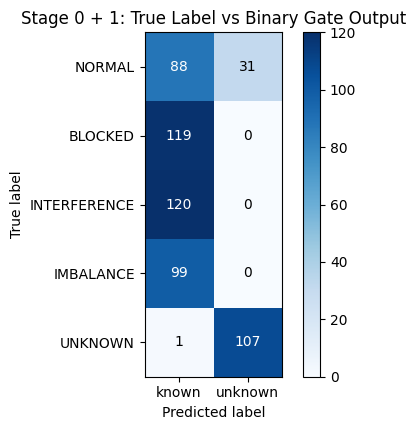

 accuracy  known_false_positive_rate  unknown_recall  stage0_rejected_windows  stage0_rejected_known  stage0_rejected_unknown  fallback_threshold  total_prototypes  file_window_q  threshold_margin  ambiguity_ratio_threshold
 0.943363                   0.067834        0.990741                      138                     31                      107           41.875705                 9           0.99               2.1                        1.0

Per-class distance thresholds calibrated from per-file train+val scores:
 label   class_name  threshold  base_file_score  train_files  val_files  calibration_files  num_prototypes  cluster_sizes  silhouette_score  file_score_median  file_score_max                       calibration_mode  used_fallback
     0       NORMAL  19.283522         9.182630            8          3                 11               3 [103, 33, 203]          0.380327           4.028497        9.182630 per-file train+val own-nearest windows          False
     1      BLOCKED 

In [115]:
gatekeeper = fit_mahalanobis_gatekeeper(
    X_train_known,
    y_train_known_raw,
    X_val_known,
    y_val_known_raw,
    known_train_feature_groups,
    known_val_feature_groups,
)
gatekeeper_save_path = ANOMALY_GATE_ARTIFACT_PATH
save_mahalanobis_gatekeeper(
    gatekeeper_save_path,
    gatekeeper,
    mean=mean,
    std=std,
    window_len=target_len,
    preprocessor_name=selected_preprocessor_name,
    preprocessor_kwargs=selected_preprocessor_kwargs,
    stage0_guard=stage0_guard,
)
print(f"Saved anomaly detector artifact to {gatekeeper_save_path}")
stage1_test_accepted = predict_gatekeeper(gatekeeper, X_full_test)

y_stage1_true_binary = (y_full_test_all_raw == UNKNOWN_LABEL).astype(np.int64)
y_stage1_pred = np.ones(len(y_full_test_all_raw), dtype=np.int64)
y_stage1_pred[full_test_stage0_accepted_indices] = stage1_test_accepted["is_unknown"]

stage1_cm = confusion_matrix(y_stage1_true_binary, y_stage1_pred, labels=[0, 1])
tn, fp, fn, tp = stage1_cm.ravel()
full_test_stage0_rejected = np.asarray(full_test_stage0["rejected_mask"], dtype=bool)
stage1_summary = pd.DataFrame([
    {
        "accuracy": accuracy_score(y_stage1_true_binary, y_stage1_pred),
        "known_false_positive_rate": fp / (fp + tn + 1e-12),
        "unknown_recall": tp / (tp + fn + 1e-12),
        "stage0_rejected_windows": int(np.sum(full_test_stage0_rejected)),
        "stage0_rejected_known": int(np.sum(full_test_stage0_rejected & (y_full_test_all_raw != UNKNOWN_LABEL))),
        "stage0_rejected_unknown": int(np.sum(full_test_stage0_rejected & (y_full_test_all_raw == UNKNOWN_LABEL))),
        "fallback_threshold": gatekeeper["fallback_threshold"],
        "total_prototypes": len(gatekeeper["prototype_table"]),
        "file_window_q": FILE_WINDOW_SCORE_Q,
        "threshold_margin": FILE_THRESHOLD_MARGIN,
        "ambiguity_ratio_threshold": gatekeeper["ambiguity_ratio_threshold"],
    }
])
threshold_table = pd.DataFrame([
    {
        "label": label,
        "class_name": LABEL_TO_NAME.get(label, str(label)),
        "threshold": details["threshold"],
        "base_file_score": details["base_file_score"],
        "train_files": details["num_train_files"],
        "val_files": details["num_val_files"],
        "calibration_files": details["num_calibration_files"],
        "num_prototypes": details["num_prototypes"],
        "cluster_sizes": details["cluster_sizes"],
        "silhouette_score": details["silhouette_score"],
        "file_score_median": details["file_score_median"],
        "file_score_max": details["file_score_max"],
        "calibration_mode": details["calibration_mode"],
        "used_fallback": details["used_fallback"],
    }
    for label, details in sorted(gatekeeper["threshold_details"].items())
])
stage1_true_label_order = known_labels + [UNKNOWN_LABEL]
stage1_true_vs_binary_cm = plot_true_label_binary_confusion(
    y_full_test_all_raw,
    y_stage1_pred,
    true_labels=stage1_true_label_order,
    true_display_labels=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    title="Stage 0 + 1: True Label vs Binary Gate Output",
    figsize=(5.8, 4.4),
)
stage1_true_vs_binary_df = pd.DataFrame(
    stage1_true_vs_binary_cm,
    index=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    columns=["known", "unknown"],
)
stage1_nearest_label_order = known_labels
stage1_true_vs_nearest_known_cm = np.zeros((len(stage1_true_label_order), len(stage1_nearest_label_order)), dtype=int)
for row, true_label in enumerate(stage1_true_label_order):
    mask = y_full_test_raw == true_label
    for col, pred_label in enumerate(stage1_nearest_label_order):
        stage1_true_vs_nearest_known_cm[row, col] = int(np.sum(mask & (stage1_test_accepted["nearest_label"] == pred_label)))
stage1_true_vs_nearest_known_df = pd.DataFrame(
    stage1_true_vs_nearest_known_cm,
    index=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    columns=[LABEL_TO_NAME[label] for label in stage1_nearest_label_order],
)
stage1_geometry_table = pd.DataFrame([
    {
        "true_label": LABEL_TO_NAME[label],
        "distance_median": float(np.median(stage1_test_accepted["distance"][y_full_test_raw == label])),
        "distance_max": float(np.max(stage1_test_accepted["distance"][y_full_test_raw == label])),
        "second_distance_median": float(np.median(stage1_test_accepted["second_distance"][y_full_test_raw == label])),
        "ratio_median": float(np.median(stage1_test_accepted["distance_ratio"][y_full_test_raw == label])),
        "ratio_max": float(np.max(stage1_test_accepted["distance_ratio"][y_full_test_raw == label])),
        "gap_median": float(np.median(stage1_test_accepted["distance_gap"][y_full_test_raw == label])),
    }
    for label in stage1_true_label_order
    if np.any(y_full_test_raw == label)
])
print(stage1_summary.to_string(index=False))
print()
print("Per-class distance thresholds calibrated from per-file train+val scores:")
print(threshold_table.to_string(index=False))
print()
print("Stage 0 + 1 confusion matrix with true labels on rows and binary gate output on columns:")
print(stage1_true_vs_binary_df.to_string())
print()
print("Nearest known label on Stage 0-accepted windows before thresholding:")
print(stage1_true_vs_nearest_known_df.to_string())
print()
print("Stage 1 distance and ambiguity stats on Stage 0-accepted windows by true label:")
print(stage1_geometry_table.to_string(index=False))
print()
print(classification_report(
    y_stage1_true_binary,
    y_stage1_pred,
    labels=[0, 1],
    target_names=["known", "unknown"],
    zero_division=0,
))


## Section 2: Fault classifier

Train the 1D CNN from `new2.ipynb` on the known labels only, then report the labelled confusion matrix on the known test split.
        

hybrid_group_norm epoch=01 train_loss=0.6892 val_loss=0.8645 val_acc=0.5908 lr=1.00e-03
hybrid_group_norm epoch=02 train_loss=0.3634 val_loss=0.9805 val_acc=0.7435 lr=1.00e-03
hybrid_group_norm epoch=03 train_loss=0.2786 val_loss=0.8590 val_acc=0.7752 lr=1.00e-03
hybrid_group_norm epoch=04 train_loss=0.2457 val_loss=1.1360 val_acc=0.6484 lr=1.00e-03
hybrid_group_norm epoch=05 train_loss=0.2372 val_loss=0.9527 val_acc=0.7378 lr=1.00e-03
hybrid_group_norm epoch=06 train_loss=0.2316 val_loss=1.0982 val_acc=0.6888 lr=1.00e-03
hybrid_group_norm epoch=07 train_loss=0.2296 val_loss=0.8393 val_acc=0.7925 lr=1.00e-03
hybrid_group_norm epoch=08 train_loss=0.2244 val_loss=1.1292 val_acc=0.6686 lr=1.00e-03
hybrid_group_norm epoch=09 train_loss=0.2343 val_loss=0.9127 val_acc=0.7406 lr=1.00e-03
hybrid_group_norm epoch=10 train_loss=0.2471 val_loss=1.0365 val_acc=0.7205 lr=1.00e-03
hybrid_group_norm epoch=11 train_loss=0.2236 val_loss=1.3091 val_acc=0.6196 lr=5.00e-04
hybrid_group_norm epoch=12 train

/tmp/ipykernel_224093/1313680773.py:456: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0409 02:02:05.472000 224093 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `HybridGroupNorm1DCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HybridGroupNorm1DCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
Saved ONNX classifier to /home/btanady/fourth_year/cpen491/experiment/weights/end_to_end_cnn1d_hybrid_calaug.onnx
Saved ONNX metadata to /home/btanady/fourth_year/cpen491/experiment/weights/end_to_end_cnn1d_hybrid_calaug.meta.json
Prepared runtime AdaBN bundle: disabled


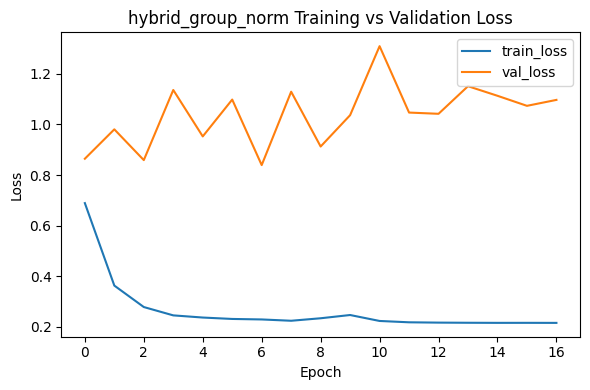

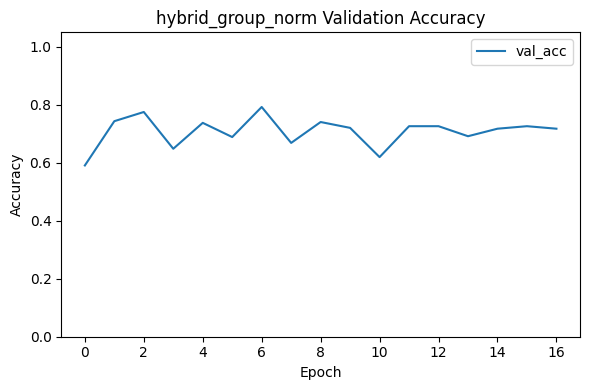

In [116]:
class ResBlock1D(nn.Module):
    def __init__(self, channels: int, kernel_size: int = 5, dilation: int = 1, dropout: float = 0.1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
        )
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.dropout(self.net(x)))


def _group_norm_groups(num_channels: int, preferred_groups: int = 8) -> int:
    capped_preferred = max(1, min(int(preferred_groups), int(num_channels)))
    for groups in range(capped_preferred, 0, -1):
        if int(num_channels) % groups == 0:
            return groups
    return 1


class ResBlock1D_V2(nn.Module):
    def __init__(self, channels: int, kernel_size: int = 5, dilation: int = 1, dropout: float = 0.1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        groups = _group_norm_groups(channels)
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.GroupNorm(num_groups=groups, num_channels=channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.GroupNorm(num_groups=groups, num_channels=channels),
        )
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.dropout(self.net(x)))


class Fan1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class Fan1DCNN_V2(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.GroupNorm(num_groups=8, num_channels=32),
            nn.ReLU(inplace=True),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.GroupNorm(num_groups=8, num_channels=64),
            nn.ReLU(inplace=True),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=128),
            nn.ReLU(inplace=True),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def extract_embedding(self, x):
        h = self.features(x)
        h = self.classifier[0](h)  # Flatten
        h = self.classifier[1](h)  # Linear(128 -> 64)
        h = self.classifier[2](h)  # ReLU
        return h

    def forward(self, x):
        return self.classifier(self.features(x))


class HybridTimeFreq1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3, width: int = 48):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=9, padding=4),
            nn.BatchNorm1d(width),
            nn.GELU(),
        )
        self.time_branch = nn.Sequential(
            ResBlock1D(width, kernel_size=7, dilation=1, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D(width, kernel_size=5, dilation=2, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D(width, kernel_size=3, dilation=4, dropout=0.1),
            nn.AdaptiveAvgPool1d(1),
        )
        self.freq_branch = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=5, padding=2),
            nn.BatchNorm1d(width),
            nn.GELU(),
            ResBlock1D(width, kernel_size=5, dilation=1, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D(width, kernel_size=3, dilation=2, dropout=0.1),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 2, 128),
            nn.GELU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        time_features = self.time_branch(self.stem(x))
        freq_input = torch.log1p(torch.abs(torch.fft.rfft(x, dim=2)))
        freq_features = self.freq_branch(freq_input)
        return self.classifier(torch.cat([time_features, freq_features], dim=1))


class HybridGroupNorm1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3, width: int = 48):
        super().__init__()
        width_groups = _group_norm_groups(width)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=9, padding=4),
            nn.GroupNorm(num_groups=width_groups, num_channels=width),
            nn.GELU(),
        )
        self.time_branch = nn.Sequential(
            ResBlock1D_V2(width, kernel_size=7, dilation=1, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D_V2(width, kernel_size=5, dilation=2, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D_V2(width, kernel_size=3, dilation=4, dropout=0.1),
            nn.AdaptiveAvgPool1d(1),
        )
        self.freq_branch = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=5, padding=2),
            nn.GroupNorm(num_groups=width_groups, num_channels=width),
            nn.GELU(),
            ResBlock1D_V2(width, kernel_size=5, dilation=1, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D_V2(width, kernel_size=3, dilation=2, dropout=0.1),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 2, 128),
            nn.GELU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        time_features = self.time_branch(self.stem(x))
        freq_input = torch.log1p(torch.abs(torch.fft.rfft(x, dim=2)))
        freq_features = self.freq_branch(freq_input)
        return self.classifier(torch.cat([time_features, freq_features], dim=1))


def build_classifier_model(n_classes: int, in_channels: int) -> nn.Module:
    architecture_key = str(CNN_ARCHITECTURE).strip().lower()
    if architecture_key == "fan1d":
        return Fan1DCNN(n_classes=n_classes, in_channels=in_channels)
    if architecture_key in {"fan1d_v2", "fan1dcnn_v2"}:
        return Fan1DCNN_V2(n_classes=n_classes, in_channels=in_channels)
    if architecture_key == "hybrid_timefreq":
        return HybridTimeFreq1DCNN(n_classes=n_classes, in_channels=in_channels)
    if architecture_key in {"hybrid_group_norm", "hybrid_groupnorm", "hybrid_timefreq_v2", "hybrid_v2"}:
        return HybridGroupNorm1DCNN(n_classes=n_classes, in_channels=in_channels)
    raise ValueError(f"Unsupported CNN_ARCHITECTURE: {CNN_ARCHITECTURE}")


def make_loader(x_np, y_np, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(x_np).float(), torch.from_numpy(y_np).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def reset_stage2_seeds(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _iter_batchnorm_layers(model):
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            yield module


@torch.no_grad()
def recalibrate_batchnorm_stats(model, x_np, *, batch_size: int | None = None, ema_momentum: float = ADABN_EMA_MOMENTUM):
    x_np = np.asarray(x_np, dtype=np.float32)
    if x_np.ndim != 3:
        raise ValueError(f"Expected AdaBN tensor with shape [N, C, T], got {x_np.shape}.")
    if x_np.shape[0] <= 0:
        raise ValueError("AdaBN recalibration requires at least one window.")
    if not (0.0 < float(ema_momentum) <= 1.0):
        raise ValueError(f"ema_momentum must be in (0, 1], got {ema_momentum}.")

    bn_layers = list(_iter_batchnorm_layers(model))
    if not bn_layers:
        return {
            "bn_layers": 0,
            "adaptation_windows": int(x_np.shape[0]),
            "adaptation_batch_size": int(x_np.shape[0]),
            "adaptation_batches": 1,
        }

    old_training_mode = bool(model.training)
    old_momentums = []
    old_track_running_stats = []
    old_training_modes = []

    for param in model.parameters():
        param.requires_grad_(False)

    model.eval()
    for module in bn_layers:
        old_momentums.append(module.momentum)
        old_track_running_stats.append(bool(module.track_running_stats))
        old_training_modes.append(bool(module.training))
        module.train()
        module.track_running_stats = True
        module.momentum = float(ema_momentum)

    effective_batch_size = int(x_np.shape[0]) if batch_size is None or int(batch_size) <= 0 else int(batch_size)
    effective_batch_size = max(1, min(effective_batch_size, int(x_np.shape[0])))
    batches = 0
    for start in range(0, int(x_np.shape[0]), effective_batch_size):
        xb = torch.from_numpy(x_np[start:start + effective_batch_size]).float().to(DEVICE)
        _ = model(xb)
        batches += 1

    for module, momentum, track_running_stats, training_mode in zip(bn_layers, old_momentums, old_track_running_stats, old_training_modes):
        module.momentum = momentum
        module.track_running_stats = track_running_stats
        module.train(training_mode)

    if old_training_mode:
        model.train()
    else:
        model.eval()

    return {
        "bn_layers": int(len(bn_layers)),
        "adaptation_windows": int(x_np.shape[0]),
        "adaptation_batch_size": int(effective_batch_size),
        "adaptation_batches": int(batches),
        "ema_momentum": float(ema_momentum),
    }


def adapt_classifier_bundle_with_bn(bundle, x_np, *, batch_size: int | None = None, ema_momentum: float = ADABN_EMA_MOMENTUM):
    adapted_bundle = copy.deepcopy(bundle)
    adapted_bundle["bn_adaptation"] = recalibrate_batchnorm_stats(
        adapted_bundle["model"],
        x_np,
        batch_size=batch_size,
        ema_momentum=ema_momentum,
    )
    return adapted_bundle


def train_cnn_classifier(
    x_train,
    y_train,
    x_val,
    y_val,
    *,
    label_to_idx,
    idx_to_label,
    save_path,
):
    reset_stage2_seeds()

    train_loader = make_loader(x_train, y_train, CNN_BATCH_SIZE, shuffle=True)
    val_loader = make_loader(x_val, y_val, CNN_BATCH_SIZE, shuffle=False)

    input_channels = int(x_train.shape[1])
    model = build_classifier_model(n_classes=len(label_to_idx), in_channels=input_channels).to(DEVICE)
    counts = np.bincount(y_train, minlength=len(label_to_idx)).astype(np.float32)
    class_weights = counts.sum() / np.maximum(counts * len(label_to_idx), 1.0)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE),
        label_smoothing=CNN_LABEL_SMOOTHING,
    )
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        total_loss = 0.0
        all_true = []
        all_pred = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_true.append(yb.cpu().numpy())
            all_pred.append(preds.cpu().numpy())

        y_true = np.concatenate(all_true)
        y_pred = np.concatenate(all_pred)
        avg_loss = total_loss / max(len(loader.dataset), 1)
        acc = accuracy_score(y_true, y_pred)
        return avg_loss, acc, y_true, y_pred

    def train_one_epoch(loader):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            xb = apply_random_amplitude_scaling_batch(xb)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)
        return total_loss / max(len(loader.dataset), 1)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_metric = (-1.0, float("inf"))
    wait = 0

    for epoch in range(1, CNN_EPOCHS + 1):
        train_loss = train_one_epoch(train_loader)
        val_loss, val_acc, _, _ = evaluate(val_loader)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"{CNN_ARCHITECTURE} epoch={epoch:02d} train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} lr={lr_now:.2e}"
        )

        metric = (val_acc, -val_loss)
        if metric > best_metric:
            best_metric = metric
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= CNN_EARLY_STOP_PATIENCE:
                print("Early stopping triggered.")
                break

    if best_state is None:
        raise RuntimeError("Training did not produce a valid CNN state.")

    model.load_state_dict(best_state)
    state_dict = model.state_dict()
    adabn_supported_for_model = any(True for _ in _iter_batchnorm_layers(model))
    if CNN_ARCHITECTURE == "fan1d_v2":
        if not isinstance(model, Fan1DCNN_V2):
            raise RuntimeError(
                f"fan1d_v2 export expected Fan1DCNN_V2, got {type(model).__name__}. "
                "Restart the kernel and rerun the model-definition cells before exporting."
            )
        classifier_weight_shape = tuple(int(v) for v in state_dict["classifier.1.weight"].shape)
        if classifier_weight_shape != (64, 128):
            raise RuntimeError(
                f"fan1d_v2 checkpoint shape mismatch: expected classifier.1.weight (64, 128), got {classifier_weight_shape}. "
                "Restart the kernel and rerun the model-definition cells before exporting."
            )

    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": state_dict,
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "mean": classifier_mean.astype(np.float32),
            "std": classifier_std.astype(np.float32),
            "classifier_input_normalization": (
                "global_zscore" if CLASSIFIER_SECOND_GLOBAL_ZSCORE else "identity"
            ),
            "window_len": int(target_len),
            "architecture": CNN_ARCHITECTURE,
            "preprocessor_name": selected_preprocessor_name,
            "preprocessor_kwargs": selected_preprocessor_kwargs,
            "drop_z_axis": bool(DROP_Z_AXIS),
            "model_axis_names": list(MODEL_AXIS_NAMES),
        },
        save_path,
    )
    print(f"Saved best {CNN_ARCHITECTURE} CNN to {save_path}")

    onnx_path = save_path.with_suffix(".onnx")
    meta_path = onnx_path.with_suffix(".meta.json")
    model.eval()
    dummy = torch.randn(1, input_channels, target_len, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        torch.onnx.export(
            model,
            dummy,
            onnx_path.as_posix(),
            export_params=True,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["logits"],
            dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
            opset_version=CNN_ONNX_OPSET,
        )

    meta = {
        "torch_path": save_path.as_posix(),
        "onnx_path": onnx_path.as_posix(),
        "input_shape": [1, input_channels, int(target_len)],
        "architecture": CNN_ARCHITECTURE,
        "embedder": {
            "name": "raw1dcnn",
            "kwargs": {
                "target_len": int(target_len),
                "mean": classifier_mean.reshape(-1).astype(float).tolist(),
                "std": classifier_std.reshape(-1).astype(float).tolist(),
            },
        },
        "preprocessor": {
            "name": selected_preprocessor_name,
            "kwargs": selected_preprocessor_kwargs,
        },
        "labels": {int(k): int(v) for k, v in idx_to_label.items()},
        "drop_z_axis": bool(DROP_Z_AXIS),
        "model_axis_names": list(MODEL_AXIS_NAMES),
        "runtime_calibration": {
            "adabn": {
                "enabled": bool(ADABN_RUNTIME_CALIBRATION and adabn_supported_for_model),
                "method": "batchnorm_running_stats" if adabn_supported_for_model else "none",
                "ema_momentum": float(ADABN_EMA_MOMENTUM),
                "model_format": "torch",
            },
        },
    }
    meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"Saved ONNX classifier to {onnx_path}")
    print(f"Saved ONNX metadata to {meta_path}")

    return {
        "model": model,
        "history": history,
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "save_path": save_path,
        "onnx_path": onnx_path,
        "meta_path": meta_path,
    }


@torch.no_grad()
def predict_cnn(bundle, x_np, batch_size=256):
    model = bundle["model"]
    model.eval()
    preds = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)
        logits = model(xb)
        pred_idx = torch.argmax(logits, dim=1).cpu().numpy()
        preds.append(pred_idx)
    pred_idx = np.concatenate(preds)
    return np.array([bundle["idx_to_label"][int(idx)] for idx in pred_idx], dtype=np.int64)


def _sanitize_feature_matrix(x_np):
    arr = np.asarray(x_np, dtype=np.float32)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def train_ml2_lda_classifier(
    train_windows,
    train_labels_raw,
    val_windows,
    val_labels_raw,
    *,
    save_path,
):
    train_windows = list(train_windows)
    val_windows = list(val_windows)
    y_train = np.asarray(train_labels_raw, dtype=np.int64).reshape(-1)
    y_val = np.asarray(val_labels_raw, dtype=np.int64).reshape(-1)

    if len(train_windows) != int(y_train.shape[0]):
        raise ValueError(
            f"train_windows/labels length mismatch: {len(train_windows)} vs {int(y_train.shape[0])}"
        )
    if len(val_windows) != int(y_val.shape[0]):
        raise ValueError(
            f"val_windows/labels length mismatch: {len(val_windows)} vs {int(y_val.shape[0])}"
        )

    embedder = MLEmbedder2(**ML2_EMBEDDER_KWARGS)
    x_train = _sanitize_feature_matrix(embedder.embed(train_windows))
    if x_train.ndim != 2 or x_train.shape[0] == 0:
        raise ValueError(f"MLEmbedder2 produced invalid training features with shape {x_train.shape}.")

    model = make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver="svd"),
    )
    model.fit(x_train, y_train)

    val_acc = float("nan")
    if val_windows:
        x_val = _sanitize_feature_matrix(embedder.embed(val_windows))
        val_pred = np.asarray(model.predict(x_val), dtype=np.int64)
        val_acc = float(accuracy_score(y_val, val_pred))

    print(
        "ml_lda training complete:",
        {
            "train_samples": int(x_train.shape[0]),
            "num_features": int(x_train.shape[1]),
            "val_samples": int(len(val_windows)),
            "val_acc": None if not np.isfinite(val_acc) else round(val_acc, 4),
        },
    )

    if joblib is None:
        raise ImportError("ml_lda backend requires joblib to be installed.")
    save_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, save_path)
    print(f"Saved ML2+LDA classifier to {save_path}")

    meta_path = save_path.with_suffix(".meta.json")
    labels_sorted = sorted({int(v) for v in np.unique(y_train)})
    meta = {
        "sklearn_path": save_path.as_posix(),
        "classifier": {
            "name": "LinearDiscriminantAnalysis",
            "backend": "ml_lda",
            "pipeline": ["StandardScaler", "LinearDiscriminantAnalysis"],
        },
        "embedder": {
            "name": "ml2",
            "kwargs": dict(ML2_EMBEDDER_KWARGS),
        },
        "preprocessor": {
            "name": selected_preprocessor_name,
            "kwargs": selected_preprocessor_kwargs,
        },
        "labels": {int(label): int(label) for label in labels_sorted},
        "runtime_calibration": {
            "adabn": {
                "enabled": False,
                "method": "none",
                "model_format": "sklearn",
            },
        },
        "feature_names": embedder.feature_names(),
    }
    meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"Saved sklearn metadata to {meta_path}")

    return {
        "model": model,
        "embedder": embedder,
        "history": {
            "val_acc": [] if not np.isfinite(val_acc) else [float(val_acc)],
        },
        "save_path": save_path,
        "meta_path": meta_path,
        "backend": "ml2_lda",
    }


def predict_ml_lda(bundle, windows_pre):
    if windows_pre is None:
        raise ValueError("predict_ml_lda requires windows_pre input.")
    windows = list(windows_pre)
    features = _sanitize_feature_matrix(bundle["embedder"].embed(windows))
    return np.asarray(bundle["model"].predict(features), dtype=np.int64)


def predict_classifier(bundle, *, x_np=None, windows_pre=None, batch_size=256):
    backend = str(bundle.get("backend", "")).strip().lower()
    if backend == "cnn1d":
        if x_np is None:
            raise ValueError("predict_classifier(backend='cnn1d') requires x_np input.")
        return predict_cnn(bundle, x_np, batch_size=batch_size)
    if backend == "ml2_lda":
        return predict_ml_lda(bundle, windows_pre)
    raise ValueError(f"Unsupported classifier bundle backend: {backend!r}")


if True:
    if CLASSIFIER_BACKEND == "cnn1d":
        source_classifier_bundle = train_cnn_classifier(
            X_train_classifier,
            y_train_classifier,
            X_val_classifier_input,
            y_val_classifier,
            label_to_idx=classifier_label_to_idx,
            idx_to_label=classifier_idx_to_label,
            save_path=CLASSIFIER_ARTIFACT_PATH,
        )

        runtime_adapted_classifier_bundle = source_classifier_bundle
        runtime_adabn_supported = any(True for _ in _iter_batchnorm_layers(source_classifier_bundle["model"]))
        if ADABN_RUNTIME_CALIBRATION and adabn_calibration_input is not None and runtime_adabn_supported:
            runtime_adapted_classifier_bundle = adapt_classifier_bundle_with_bn(
                source_classifier_bundle,
                adabn_calibration_input,
                ema_momentum=ADABN_EMA_MOMENTUM,
            )
            print("Prepared runtime AdaBN bundle:", runtime_adapted_classifier_bundle["bn_adaptation"])
        elif ADABN_RUNTIME_CALIBRATION and adabn_calibration_input is not None and not runtime_adabn_supported:
            print("Prepared runtime AdaBN bundle: disabled (selected CNN architecture has no BatchNorm layers)")
        else:
            print("Prepared runtime AdaBN bundle: disabled")

        source_classifier_bundle["backend"] = "cnn1d"

    elif CLASSIFIER_BACKEND == "ml_lda":
        source_classifier_bundle = train_ml2_lda_classifier(
            classifier_train_pre,
            y_train_classifier_raw,
            known_val_pre,
            y_val_known_raw,
            save_path=CLASSIFIER_ARTIFACT_PATH,
        )
        runtime_adapted_classifier_bundle = source_classifier_bundle
        print("Prepared runtime AdaBN bundle: not applicable for ml_lda/sklearn backend")

    else:
        raise ValueError(f"Unsupported CLASSIFIER_BACKEND: {CLASSIFIER_BACKEND!r}")

    classifier_bundle = source_classifier_bundle

    if classifier_bundle["backend"] == "cnn1d":
        plt.figure(figsize=(6, 4))
        plt.plot(classifier_bundle["history"]["train_loss"], label="train_loss")
        plt.plot(classifier_bundle["history"]["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{CNN_ARCHITECTURE} Training vs Validation Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.plot(classifier_bundle["history"]["val_acc"], label="val_acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1.05)
        plt.title(f"{CNN_ARCHITECTURE} Validation Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()


Known-class test accuracy on Stage 0-accepted windows: 0.913

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        88
     BLOCKED       0.78      0.97      0.86       119
INTERFERENCE       1.00      0.72      0.84       120
   IMBALANCE       0.96      1.00      0.98        99

    accuracy                           0.91       426
   macro avg       0.93      0.92      0.92       426
weighted avg       0.93      0.91      0.91       426



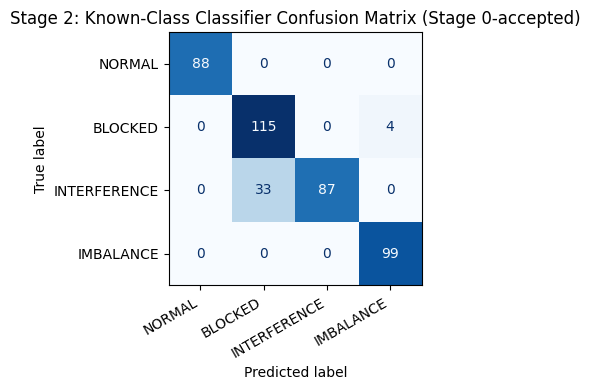

array([[ 88,   0,   0,   0],
       [  0, 115,   0,   4],
       [  0,  33,  87,   0],
       [  0,   0,   0,  99]])

In [117]:
y_known_test_pred = predict_classifier(
    source_classifier_bundle,
    x_np=X_known_test_classifier_input,
    windows_pre=known_test_pre,
)

print(f"Known-class test accuracy on Stage 0-accepted windows: {accuracy_score(y_known_test_raw, y_known_test_pred):.3f}")
print()
print(classification_report(
    y_known_test_raw,
    y_known_test_pred,
    labels=known_labels,
    target_names=[LABEL_TO_NAME[label] for label in known_labels],
    zero_division=0,
))
plot_confusion(
    y_known_test_raw,
    y_known_test_pred,
    labels=known_labels,
    display_labels=[LABEL_TO_NAME[label] for label in known_labels],
    title="Stage 2: Known-Class Classifier Confusion Matrix (Stage 0-accepted)",
    figsize=(4.8, 4.0),
)


## Evaluation

Run the full cascade on the held-out test split. Stage 0 screens malformed or off-scale windows, Stage 1 decides whether the remaining samples are unknown, and only samples kept as known are allowed through to the CNN classifier.


 combined_accuracy  num_known_test_windows  num_unknown_test_windows  predicted_unknown_windows
          0.877876                     457                       108                        138

              precision    recall  f1-score   support

      NORMAL       0.99      0.74      0.85       119
     BLOCKED       0.78      0.97      0.86       119
INTERFERENCE       1.00      0.72      0.84       120
   IMBALANCE       0.96      1.00      0.98        99
     UNKNOWN       0.78      0.99      0.87       108

    accuracy                           0.88       565
   macro avg       0.90      0.88      0.88       565
weighted avg       0.90      0.88      0.88       565



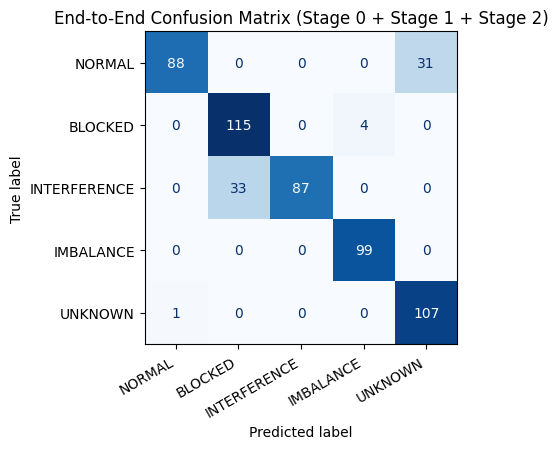

array([[ 88,   0,   0,   0,  31],
       [  0, 115,   0,   4,   0],
       [  0,  33,  87,   0,   0],
       [  0,   0,   0,  99,   0],
       [  1,   0,   0,   0, 107]])

In [118]:
y_full_classifier_pred = predict_classifier(
    source_classifier_bundle,
    x_np=X_full_test_classifier_input,
    windows_pre=full_test_pre,
)
y_combined_pred = np.full(len(y_full_test_all_raw), UNKNOWN_LABEL, dtype=np.int64)
stage1_known_mask = stage1_test_accepted["is_unknown"] == 0
stage1_known_indices = full_test_stage0_accepted_indices[stage1_known_mask]
y_combined_pred[stage1_known_indices] = y_full_classifier_pred[stage1_known_mask]

combined_labels = known_labels + [UNKNOWN_LABEL]
combined_summary = pd.DataFrame([
    {
        "combined_accuracy": accuracy_score(y_full_test_all_raw, y_combined_pred),
        "num_known_test_windows": int(np.sum(y_full_test_all_raw != UNKNOWN_LABEL)),
        "num_unknown_test_windows": int(np.sum(y_full_test_all_raw == UNKNOWN_LABEL)),
        "predicted_unknown_windows": int(np.sum(y_combined_pred == UNKNOWN_LABEL)),
    }
])
print(combined_summary.to_string(index=False))
print()
print(classification_report(
    y_full_test_all_raw,
    y_combined_pred,
    labels=combined_labels,
    target_names=[LABEL_TO_NAME[label] for label in combined_labels],
    zero_division=0,
))
plot_confusion(
    y_full_test_all_raw,
    y_combined_pred,
    labels=combined_labels,
    display_labels=[LABEL_TO_NAME[label] for label in combined_labels],
    title="End-to-End Confusion Matrix (Stage 0 + Stage 1 + Stage 2)",
    figsize=(5.8, 4.6),
)


In [119]:
import shlex


def _display_path(path_like) -> str:
    path = Path(path_like)
    try:
        return path.relative_to(ROOT).as_posix()
    except ValueError:
        return path.as_posix()


broker_model_path = _display_path(classifier_bundle["save_path"])
broker_gate_path = _display_path(gatekeeper_save_path)

broker_backend = str(classifier_bundle.get("backend", "cnn1d")).strip().lower()
if broker_backend == "cnn1d":
    broker_model_format = "torch"
    broker_embedder = "auto"
    cnn_architecture_key = str(CNN_ARCHITECTURE).strip().lower()
    cnn_arch_supports_adabn = cnn_architecture_key in {"fan1d", "hybrid_timefreq"}
    broker_adabn_enabled = bool(ADABN_RUNTIME_CALIBRATION and cnn_arch_supports_adabn)
elif broker_backend == "ml2_lda":
    broker_model_format = "sklearn"
    broker_embedder = "ml2"
    broker_adabn_enabled = False
else:
    raise ValueError(f"Unsupported classifier backend for broker launch: {broker_backend!r}")

broker_cmd_parts = [
    "python -m fdd_system.broker.main",
    "--port /dev/ttyACM0",
    "--baudrate 115200",
    "--input-format bin",
    "--fs-hz 800",
    f"--model-path {shlex.quote(broker_model_path)}",
    f"--model-format {broker_model_format}",
    f"--embedder {broker_embedder}",
    f"--preprocessor {selected_preprocessor_name}",
    f"--anomaly-detector-path {shlex.quote(broker_gate_path)}",
    "--calibration-seconds 9",
    "--calibration-discard-seconds 1",
]

if broker_adabn_enabled:
    broker_cmd_parts.append("--adabn-runtime-calibration")
    broker_cmd_parts.append(f"--adabn-ema-momentum {ADABN_EMA_MOMENTUM:g}")
else:
    broker_cmd_parts.append("--no-adabn-runtime-calibration")

if GATE_RUNTIME_CALIBRATION:
    broker_cmd_parts.append("--gate-runtime-calibration")
else:
    broker_cmd_parts.append("--no-gate-runtime-calibration")

broker_cmd = " ".join(broker_cmd_parts)

print("Broker launch command:")
print(broker_cmd)


Broker launch command:
python -m fdd_system.broker.main --port /dev/ttyACM0 --baudrate 115200 --input-format bin --fs-hz 800 --model-path experiment/weights/end_to_end_cnn1d_hybrid_calaug.pt --model-format torch --embedder auto --preprocessor rms --anomaly-detector-path experiment/weights/end_to_end_anomaly_gate.pt --calibration-seconds 9 --calibration-discard-seconds 1 --no-adabn-runtime-calibration --gate-runtime-calibration


## Target-Domain Visualization (`target_data` path)

Set `target_data` to a CSV file or dataset directory representing target-distribution data, then run the next cell to plot decision boundaries + PCA/t-SNE overlays (source vs target), aligned with `calibration_analysis.ipynb` style.


Target file map:
  NORMAL: 2 file(s)
  BLOCKED: 1 file(s)

Target window summary:
  raw windows: 84
  stage0 accepted: 84
  preprocessed windows: 84
  labels: {'NORMAL': 70, 'BLOCKED': 14}


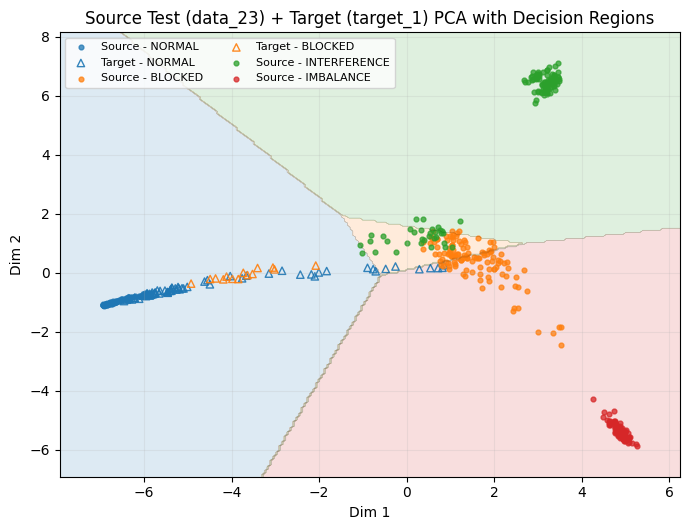

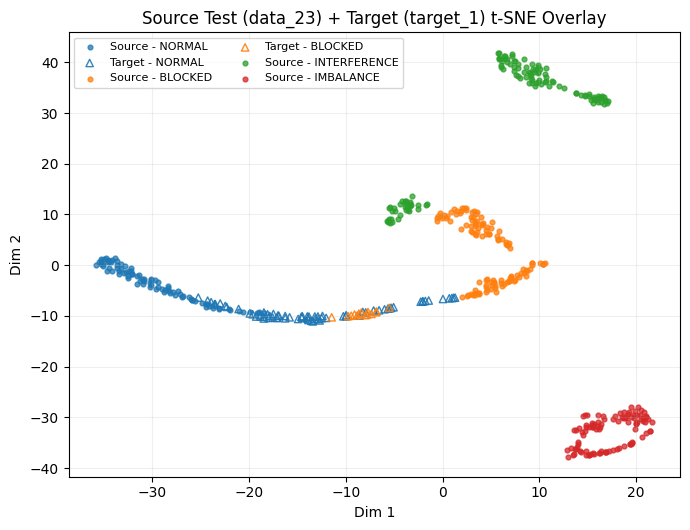

In [120]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import inspect

# Path to data collected from the target distribution.
# Supported forms:
# 1) dataset directory with subfolders (normal/blocked/interference/imbalance)
# 2) directory with CSV files directly inside (assumed normal)
# 3) single CSV file path (assumed normal)
target_data = ROOT / "experiment" / "target_1"


def _resolve_target_data_path(path_like) -> Path:
    path = Path(path_like).expanduser()
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    return path


def _collect_target_file_map(path_like) -> OrderedDict[int, list[str]]:
    base = _resolve_target_data_path(path_like)
    if not base.exists():
        raise FileNotFoundError(f"Target data path not found: {base}")

    default_label = int(KNOWN_FOLDER_TO_LABEL[CALIBRATION_FOLDER])

    if base.is_file():
        if base.suffix.lower() != ".csv":
            raise ValueError(f"Target data file must be a CSV: {base}")
        return OrderedDict([(default_label, [str(base)])])

    file_map: OrderedDict[int, list[str]] = OrderedDict()
    for folder_name, label in KNOWN_FOLDER_TO_LABEL.items():
        folder_path = base / folder_name
        if not folder_path.is_dir():
            continue
        files = sorted(str(path) for path in folder_path.glob("*.csv"))
        if files:
            file_map[int(label)] = files

    if file_map:
        return file_map

    flat_files = sorted(str(path) for path in base.glob("*.csv"))
    if flat_files:
        print(
            f"No known-label subfolders found under {base}. "
            f"Treating top-level CSVs as '{CALIBRATION_FOLDER}' ({LABEL_TO_NAME[default_label]})."
        )
        return OrderedDict([(default_label, flat_files)])

    expected = ", ".join(KNOWN_FOLDER_TO_LABEL.keys())
    raise ValueError(
        f"No CSVs found for target data at {base}. Expected subfolders: {expected}, or CSV files directly."
    )


@torch.no_grad()
def extract_classifier_embeddings(bundle, x_np, batch_size: int = 256) -> np.ndarray:
    model = bundle["model"]
    model.eval()

    embeddings = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)

        if hasattr(model, "extract_embedding"):
            emb = model.extract_embedding(xb)
        elif all(hasattr(model, attr) for attr in ["stem", "time_branch", "freq_branch", "classifier"]):
            time_features = model.time_branch(model.stem(xb))
            freq_input = torch.log1p(torch.abs(torch.fft.rfft(xb, dim=2)))
            freq_features = model.freq_branch(freq_input)
            h = torch.cat([time_features, freq_features], dim=1)
            emb = model.classifier[0](h)
            emb = model.classifier[1](emb)
            emb = model.classifier[2](emb)
        elif hasattr(model, "features") and hasattr(model, "classifier") and len(model.classifier) >= 3:
            h = model.features(xb)
            emb = model.classifier[0](h)
            emb = model.classifier[1](emb)
            emb = model.classifier[2](emb)
        else:
            raise ValueError(
                f"Unsupported classifier architecture for embedding extraction: {type(model).__name__}"
            )

        embeddings.append(emb.detach().cpu().numpy())

    if not embeddings:
        raise ValueError("No windows available for embedding extraction.")
    return np.concatenate(embeddings, axis=0)


@torch.no_grad()
def predict_labels_from_embeddings(bundle, embeddings_np: np.ndarray) -> np.ndarray:
    model = bundle["model"]
    model.eval()
    if not hasattr(model, "classifier") or len(model.classifier) < 5:
        raise ValueError(
            f"Model classifier layout is unsupported for embedding-space decision boundaries: {type(model).__name__}"
        )

    emb = torch.from_numpy(np.asarray(embeddings_np, dtype=np.float32)).to(DEVICE)
    logits = model.classifier[4](model.classifier[3](emb))
    pred_idx = torch.argmax(logits, dim=1).cpu().numpy()
    return np.array([bundle["idx_to_label"][int(idx)] for idx in pred_idx], dtype=np.int64)



def reduce_tsne(X: np.ndarray) -> np.ndarray:
    n = len(X)
    if n < 3:
        raise ValueError("t-SNE requires at least 3 samples.")

    perplexity = min(30, max(2, n - 1))
    params = {
        "n_components": 2,
        "perplexity": perplexity,
        "learning_rate": "auto",
        "init": "pca",
        "random_state": SEED,
    }
    tsne_sig = inspect.signature(TSNE.__init__).parameters
    if "max_iter" in tsne_sig:
        params["max_iter"] = 1200
    else:
        params["n_iter"] = 1200

    return TSNE(**params).fit_transform(X)



def _plot_decision_regions_on_pca_ax(
    ax,
    Z,
    known_labels_plot,
    bundle,
    pca_model,
    alpha: float = 0.15,
):
    if pca_model is None or len(known_labels_plot) < 2:
        return

    x_min, x_max = float(np.min(Z[:, 0])), float(np.max(Z[:, 0]))
    y_min, y_max = float(np.min(Z[:, 1])), float(np.max(Z[:, 1]))
    x_pad = 0.08 * max(1e-6, x_max - x_min)
    y_pad = 0.08 * max(1e-6, y_max - y_min)

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_pad, x_max + x_pad, 220),
        np.linspace(y_min - y_pad, y_max + y_pad, 220),
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid_embeddings = pca_model.inverse_transform(grid_2d).astype(np.float32)

    pred_labels = predict_labels_from_embeddings(bundle, grid_embeddings)
    label_to_idx = {int(label): idx for idx, label in enumerate(known_labels_plot)}
    pred_idx = np.array([
        label_to_idx.get(int(label), -1)
        for label in pred_labels
    ], dtype=np.int64).reshape(xx.shape)

    mask = pred_idx >= 0
    if not np.any(mask):
        return

    colors = [
        TARGET_LABEL_COLORS.get(int(label), "gray")
        for label in known_labels_plot
    ]
    levels = np.arange(len(known_labels_plot) + 1) - 0.5

    ax.contourf(xx, yy, pred_idx, levels=levels, colors=colors, alpha=alpha)
    ax.contour(xx, yy, pred_idx, levels=levels, colors="k", linewidths=0.3, alpha=0.25)



def _plot_source_target_overlay(
    ax,
    Z,
    y,
    domains,
    known_labels_plot,
    title,
    *,
    show_decision_boundary: bool,
    decision_boundary_bundle=None,
    pca_model=None,
):
    if show_decision_boundary:
        _plot_decision_regions_on_pca_ax(
            ax,
            Z,
            known_labels_plot,
            bundle=decision_boundary_bundle,
            pca_model=pca_model,
        )

    for label in known_labels_plot:
        color = TARGET_LABEL_COLORS.get(int(label), "gray")
        source_mask = (y == int(label)) & (domains == 0)
        target_mask = (y == int(label)) & (domains == 1)

        if np.any(source_mask):
            ax.scatter(
                Z[source_mask, 0],
                Z[source_mask, 1],
                s=12,
                alpha=0.75,
                marker="o",
                c=color,
                label=f"Source - {LABEL_TO_NAME[int(label)]}",
            )

        if np.any(target_mask):
            ax.scatter(
                Z[target_mask, 0],
                Z[target_mask, 1],
                s=28,
                alpha=0.9,
                marker="^",
                facecolors="none",
                edgecolors=color,
                linewidths=1.0,
                label=f"Target - {LABEL_TO_NAME[int(label)]}",
            )

    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(alpha=0.2)

    handles, labels = ax.get_legend_handles_labels()
    dedup = {}
    for handle, label in zip(handles, labels):
        if label not in dedup:
            dedup[label] = handle
    ax.legend(dedup.values(), dedup.keys(), fontsize=8, ncols=2, loc="best")


TARGET_LABEL_COLORS = {
    int(OperatingCondition.NORMAL.value): "tab:blue",
    int(OperatingCondition.BLOCKED_AIRFLOW.value): "tab:orange",
    int(OperatingCondition.INTERFERENCE.value): "tab:green",
    int(OperatingCondition.IMBALANCE.value): "tab:red",
}


target_file_map = _collect_target_file_map(target_data)
print("Target file map:")
for label, files in target_file_map.items():
    print(f"  {LABEL_TO_NAME[int(label)]}: {len(files)} file(s)")


target_raw_all = prepare_raw_windows_for_map(target_file_map, shuffle=False)
target_stage0 = stage0_details_for_windows(target_raw_all)
target_raw_pre = filter_windows_by_stage0(target_raw_all, target_stage0)

if not target_raw_pre:
    raise ValueError("No target windows survived Stage 0 filtering.")

target_pre = selected_preprocessor.preprocess(target_raw_pre)
if not target_pre:
    raise ValueError("No target windows remained after preprocessing.")

X_target_raw, y_target_raw, _ = stack_windows(target_pre, target_len=target_len)
X_target_classifier_input = apply_classifier_input_normalization(X_target_raw, classifier_mean, classifier_std)

print()
print("Target window summary:")
print(f"  raw windows: {len(target_raw_all)}")
print(f"  stage0 accepted: {len(target_raw_pre)}")
print(f"  preprocessed windows: {len(target_pre)}")
print(f"  labels: {named_label_counts(y_target_raw)}")

source_embeddings = extract_classifier_embeddings(classifier_bundle, X_known_test_classifier_input)
target_embeddings = extract_classifier_embeddings(classifier_bundle, X_target_classifier_input)

joint_embeddings = np.concatenate([source_embeddings, target_embeddings], axis=0)
joint_labels = np.concatenate([y_known_test_raw, y_target_raw], axis=0)
joint_domains = np.concatenate([
    np.zeros(len(y_known_test_raw), dtype=np.int64),
    np.ones(len(y_target_raw), dtype=np.int64),
], axis=0)

known_labels_plot = [
    int(label)
    for label in known_labels
    if np.any(joint_labels == int(label))
]
if len(known_labels_plot) < 2:
    raise ValueError("Need at least 2 known labels for decision-boundary visualization.")

pca_model = PCA(n_components=2, random_state=SEED)
joint_pca = pca_model.fit_transform(joint_embeddings)
joint_tsne = reduce_tsne(joint_embeddings)

fig, ax = plt.subplots(1, 1, figsize=(7.0, 5.4))
_plot_source_target_overlay(
    ax,
    joint_pca,
    joint_labels,
    joint_domains,
    known_labels_plot,
    title=f"Source Test ({DATASET_NAME}) + Target ({Path(target_data).name}) PCA with Decision Regions",
    show_decision_boundary=True,
    decision_boundary_bundle=classifier_bundle,
    pca_model=pca_model,
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7.0, 5.4))
_plot_source_target_overlay(
    ax,
    joint_tsne,
    joint_labels,
    joint_domains,
    known_labels_plot,
    title=f"Source Test ({DATASET_NAME}) + Target ({Path(target_data).name}) t-SNE Overlay",
    show_decision_boundary=False,
)
plt.tight_layout()
plt.show()
